## **NORMAL VS CRACKLES VS WHEEZES - 3 LABEL CLASSIFICATION USING STATISTICAL MODELS**

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

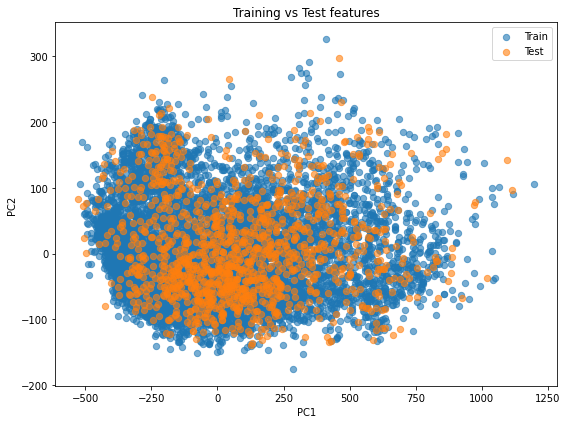

In [71]:
# Load train, test features
training_features = np.load("training_features_mean.npy")
test_features = np.load("test_features_mean.npy")

# Combine both sets
X_combined = np.vstack([training_features, test_features])
sets = np.array(["Train"] * len(training_features) + ["Test"] * len(test_features))

# PCA: retain 95% of variance
pca = PCA(n_components=0.95)
X_pca_full = pca.fit_transform(X_combined)

# Keep first 2 principal components for visualization
X_pca_vis = X_pca_full[:, :2]

plt.figure(figsize=(8, 6))
for set_name in ["Train", "Test"]:
    idx = sets == set_name
    plt.scatter(X_pca_vis[idx, 0], X_pca_vis[idx, 1], label=set_name, alpha=0.6, s=40)
plt.title("Training vs Test features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

From the PCA plot we observe a significant overlap between the training and test sets in the projected feature space. This suggests that both sets share a similar underlying distribution after feature extraction. As a result,the classification models trained on this feature representation are less likely to suffer from distribution mismatch.

### **WITHOUT DOMAIN ADAPTATION**

#### **k-NN**

Best n_neighbors (accuracy): 1 with accuracy: 0.7618
Best n_neighbors (F1 macro): 1 with F1-score: 0.7617


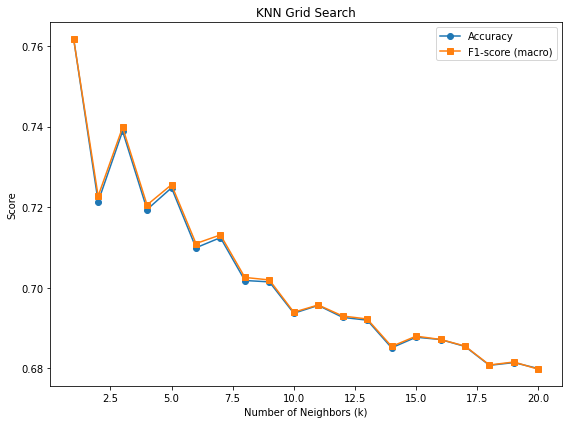

In [81]:
from statistical_models.knn import knn_grid_search

X_train = np.load("training_features_mean.npy")
y_train = np.load("training_labels.npy")
X_test = np.load("test_features_mean.npy")
y_test = np.load("test_labels.npy")

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
classes = le.classes_

# Apply MinMax Scaling 
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn_grid_search(X_train, y_train, n_splits=5, neighbor_range=range(1, 21))


Fold 1


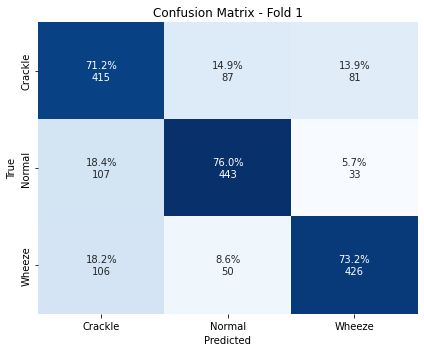

              precision    recall  f1-score   support

     Crackle       0.66      0.71      0.69       583
      Normal       0.76      0.76      0.76       583
      Wheeze       0.79      0.73      0.76       582

    accuracy                           0.73      1748
   macro avg       0.74      0.73      0.74      1748
weighted avg       0.74      0.73      0.74      1748


Fold 2


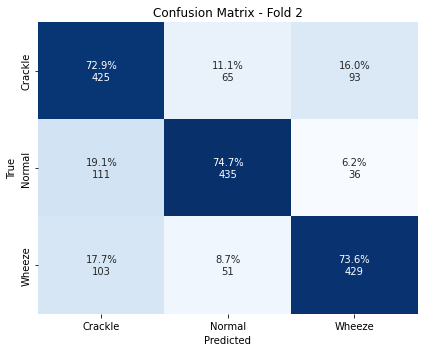

              precision    recall  f1-score   support

     Crackle       0.67      0.73      0.70       583
      Normal       0.79      0.75      0.77       582
      Wheeze       0.77      0.74      0.75       583

    accuracy                           0.74      1748
   macro avg       0.74      0.74      0.74      1748
weighted avg       0.74      0.74      0.74      1748


Fold 3


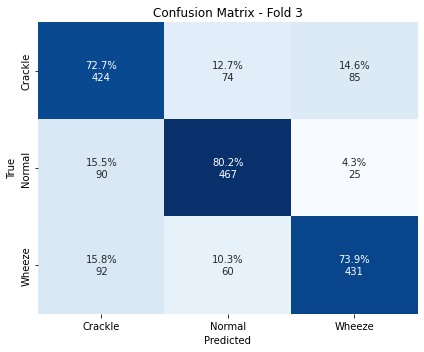

              precision    recall  f1-score   support

     Crackle       0.70      0.73      0.71       583
      Normal       0.78      0.80      0.79       582
      Wheeze       0.80      0.74      0.77       583

    accuracy                           0.76      1748
   macro avg       0.76      0.76      0.76      1748
weighted avg       0.76      0.76      0.76      1748


Fold 4


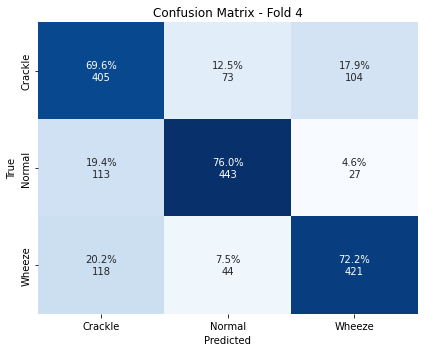

              precision    recall  f1-score   support

     Crackle       0.64      0.70      0.67       582
      Normal       0.79      0.76      0.78       583
      Wheeze       0.76      0.72      0.74       583

    accuracy                           0.73      1748
   macro avg       0.73      0.73      0.73      1748
weighted avg       0.73      0.73      0.73      1748


Fold 5


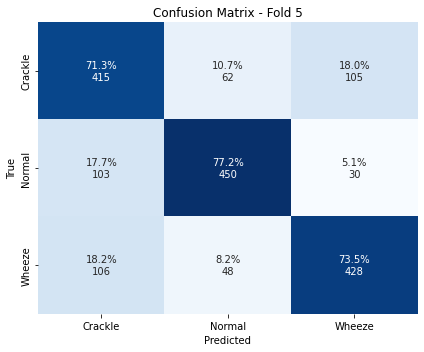

              precision    recall  f1-score   support

     Crackle       0.67      0.71      0.69       582
      Normal       0.80      0.77      0.79       583
      Wheeze       0.76      0.74      0.75       582

    accuracy                           0.74      1747
   macro avg       0.74      0.74      0.74      1747
weighted avg       0.74      0.74      0.74      1747



In [96]:
from statistical_models.knn import *

# Training
knn_model = train(X_train, y_train, classes, n_neighbors=3)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.64      0.71      0.67       373
      Normal       0.80      0.79      0.79       729
      Wheeze       0.67      0.55      0.60       177

    accuracy                           0.73      1279
   macro avg       0.70      0.68      0.69      1279
weighted avg       0.73      0.73      0.73      1279



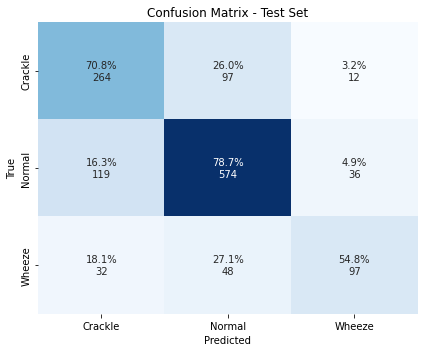

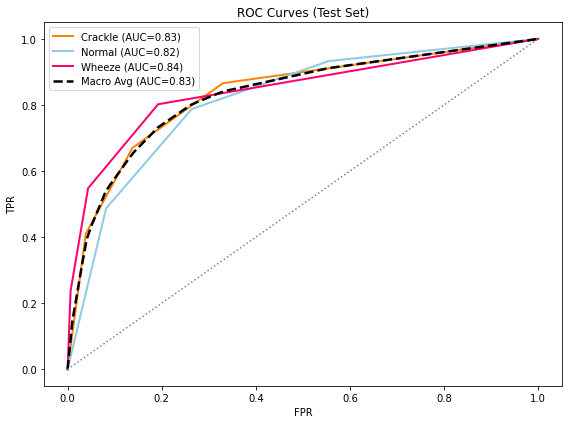

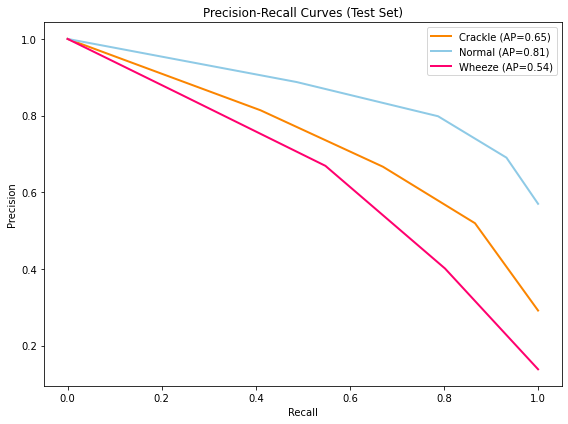

In [97]:
from statistical_models.evaluate import evaluate_model

# Evaluate on test set
knn_metrics_df = evaluate_model(X_test, y_test, classes, knn_model)

In [98]:
knn_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.707775,0.833333,0.636145,0.873843,0.525317,0.770554
1,Normal,0.787380,0.736364,0.798331,0.723214,0.522643,0.761872
2,Wheeze,0.548023,0.956443,0.668966,0.929453,0.549438,0.752233


#### **Non-Linear SVM (rbf kernel)**

Best params (accuracy): {'C': 10, 'gamma': 'scale'} acc=0.7086
Best params (F1 macro): {'C': 10, 'gamma': 'scale'} f1=0.7035


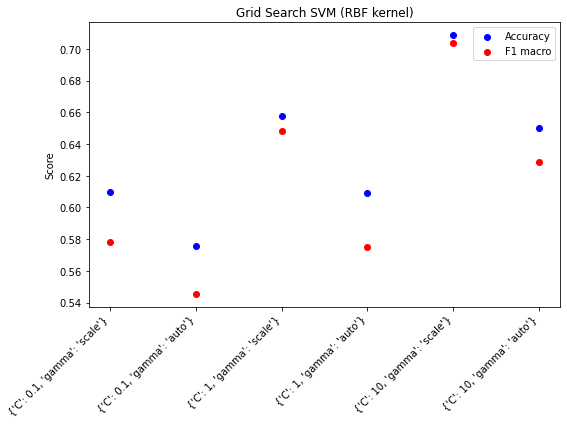

In [ ]:
from statistical_models.non_linear_svm import grid_search_svm

param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"]
}

grid = grid_search_svm(X_train, y_train, param_grid, n_splits=5)


Fold 1


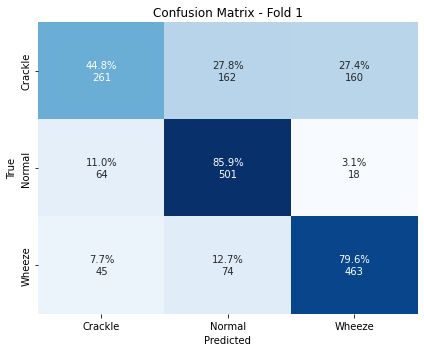

              precision    recall  f1-score   support

     Crackle       0.71      0.45      0.55       583
      Normal       0.68      0.86      0.76       583
      Wheeze       0.72      0.80      0.76       582

    accuracy                           0.70      1748
   macro avg       0.70      0.70      0.69      1748
weighted avg       0.70      0.70      0.69      1748


Fold 2


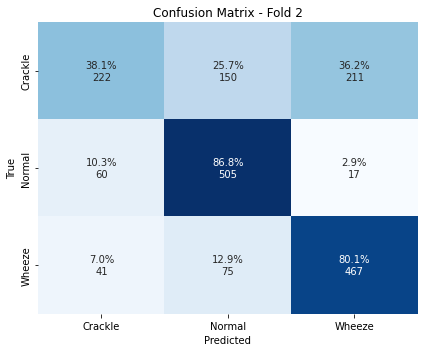

              precision    recall  f1-score   support

     Crackle       0.69      0.38      0.49       583
      Normal       0.69      0.87      0.77       582
      Wheeze       0.67      0.80      0.73       583

    accuracy                           0.68      1748
   macro avg       0.68      0.68      0.66      1748
weighted avg       0.68      0.68      0.66      1748


Fold 3


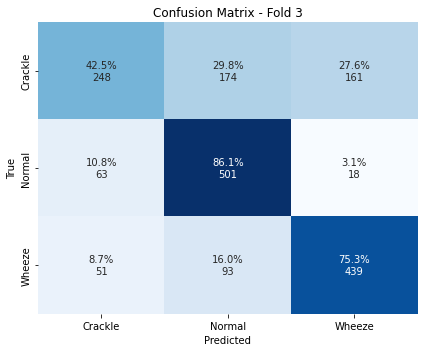

              precision    recall  f1-score   support

     Crackle       0.69      0.43      0.52       583
      Normal       0.65      0.86      0.74       582
      Wheeze       0.71      0.75      0.73       583

    accuracy                           0.68      1748
   macro avg       0.68      0.68      0.67      1748
weighted avg       0.68      0.68      0.67      1748


Fold 4


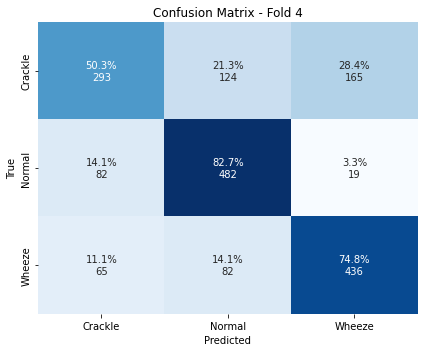

              precision    recall  f1-score   support

     Crackle       0.67      0.50      0.57       582
      Normal       0.70      0.83      0.76       583
      Wheeze       0.70      0.75      0.72       583

    accuracy                           0.69      1748
   macro avg       0.69      0.69      0.69      1748
weighted avg       0.69      0.69      0.69      1748


Fold 5


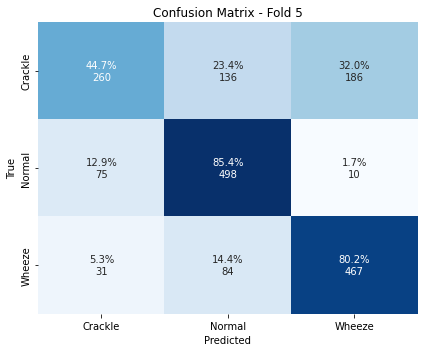

              precision    recall  f1-score   support

     Crackle       0.71      0.45      0.55       582
      Normal       0.69      0.85      0.77       583
      Wheeze       0.70      0.80      0.75       582

    accuracy                           0.70      1747
   macro avg       0.70      0.70      0.69      1747
weighted avg       0.70      0.70      0.69      1747



In [101]:
from statistical_models.non_linear_svm import train

C = grid.best_params_["C"]
gamma = grid.best_params_["gamma"]

svm_model = train(X_train, y_train, classes, n_splits=5, C=C, gamma=gamma)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.63      0.50      0.55       373
      Normal       0.69      0.86      0.76       729
      Wheeze       0.79      0.35      0.49       177

    accuracy                           0.68      1279
   macro avg       0.70      0.57      0.60      1279
weighted avg       0.69      0.68      0.66      1279



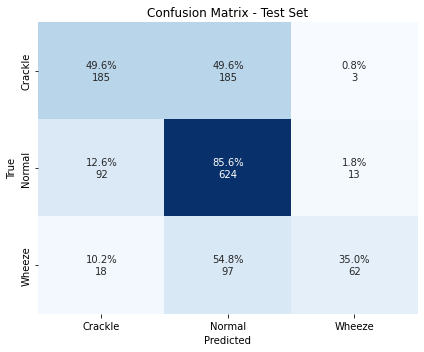

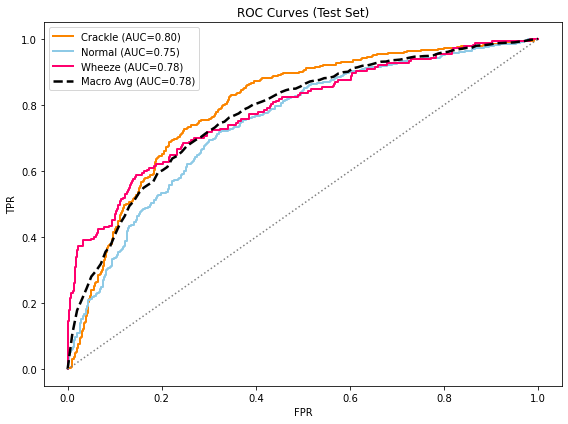

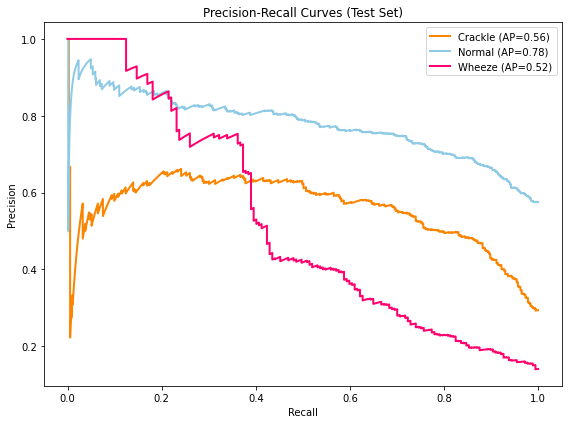

In [ ]:
from statistical_models.evaluate import evaluate_model

svm_metrics_df = evaluate_model(X_test, y_test, classes, svm_model)

In [103]:
svm_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.495979,0.878587,0.627119,0.808943,0.404146,0.687283
1,Normal,0.855967,0.487273,0.688742,0.718499,0.373873,0.671620
2,Wheeze,0.350282,0.985481,0.794872,0.904246,0.484498,0.667882


#### **Random Forest**

Best params (accuracy): {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200} acc=0.7554
Best params (F1 macro): {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200} f1=0.7521


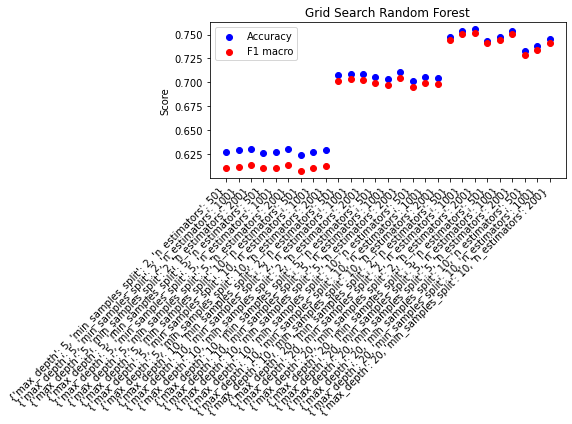

In [ ]:
from statistical_models.random_forest import rf_grid_search

# Grid search
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid = rf_grid_search(X_train, y_train, param_grid, n_splits=5)


Fold 1


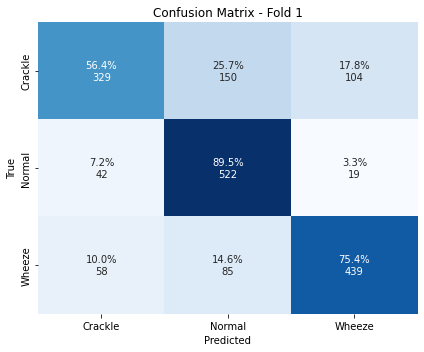

              precision    recall  f1-score   support

     Crackle       0.77      0.56      0.65       583
      Normal       0.69      0.90      0.78       583
      Wheeze       0.78      0.75      0.77       582

    accuracy                           0.74      1748
   macro avg       0.75      0.74      0.73      1748
weighted avg       0.75      0.74      0.73      1748


Fold 2


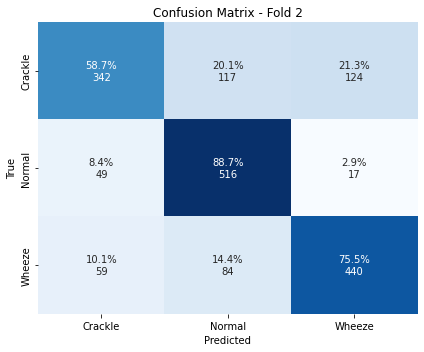

              precision    recall  f1-score   support

     Crackle       0.76      0.59      0.66       583
      Normal       0.72      0.89      0.79       582
      Wheeze       0.76      0.75      0.76       583

    accuracy                           0.74      1748
   macro avg       0.75      0.74      0.74      1748
weighted avg       0.75      0.74      0.74      1748


Fold 3


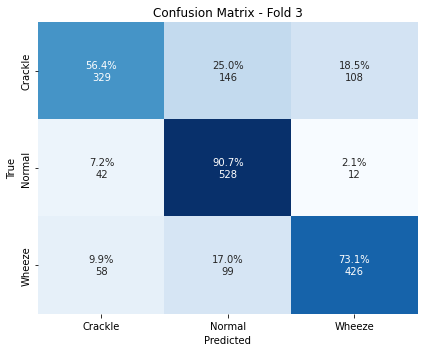

              precision    recall  f1-score   support

     Crackle       0.77      0.56      0.65       583
      Normal       0.68      0.91      0.78       582
      Wheeze       0.78      0.73      0.75       583

    accuracy                           0.73      1748
   macro avg       0.74      0.73      0.73      1748
weighted avg       0.74      0.73      0.73      1748


Fold 4


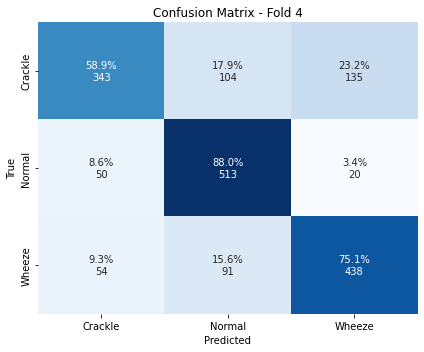

              precision    recall  f1-score   support

     Crackle       0.77      0.59      0.67       582
      Normal       0.72      0.88      0.79       583
      Wheeze       0.74      0.75      0.74       583

    accuracy                           0.74      1748
   macro avg       0.74      0.74      0.74      1748
weighted avg       0.74      0.74      0.74      1748


Fold 5


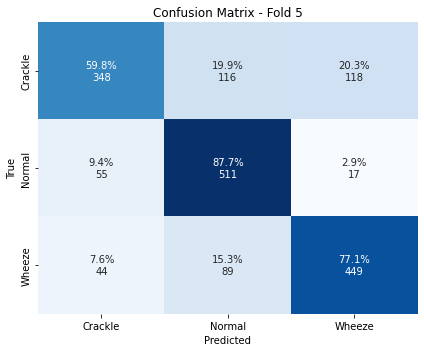

              precision    recall  f1-score   support

     Crackle       0.78      0.60      0.68       582
      Normal       0.71      0.88      0.79       583
      Wheeze       0.77      0.77      0.77       582

    accuracy                           0.75      1747
   macro avg       0.75      0.75      0.74      1747
weighted avg       0.75      0.75      0.74      1747



In [ ]:
from statistical_models.random_forest import train

# Train
best_params = {
    "n_estimators": 200,
    "max_depth": 20,
    "min_samples_split": 2
}

rf_model = train(X_train, y_train, classes, best_params)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.71      0.55      0.62       373
      Normal       0.72      0.90      0.80       729
      Wheeze       0.69      0.33      0.45       177

    accuracy                           0.72      1279
   macro avg       0.71      0.59      0.62      1279
weighted avg       0.71      0.72      0.70      1279



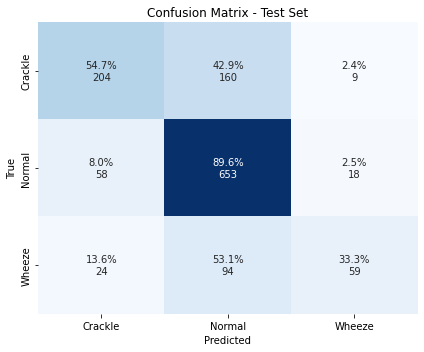

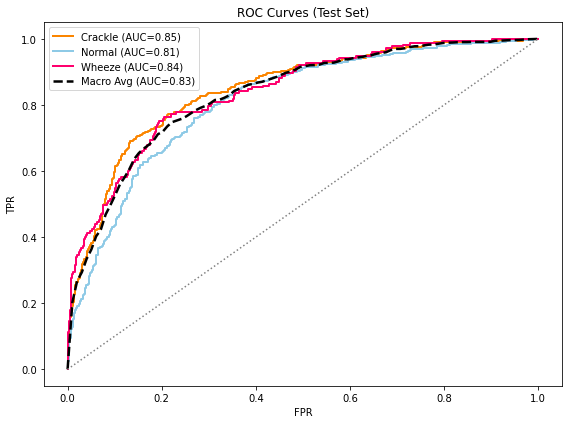

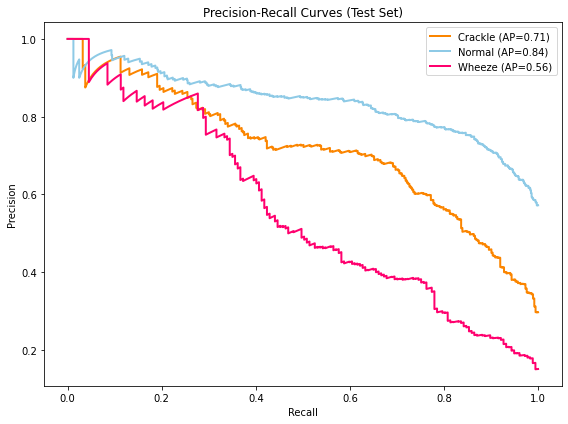

In [ ]:
from statistical_models.evaluate import evaluate_model

# Evaluate on test set
rf_metrics_df = evaluate_model(X_test, y_test, classes, rf_model)

In [44]:
rf_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.546917,0.909492,0.713287,0.829809,0.497869,0.728205
1,Normal,0.895748,0.538182,0.719956,0.795699,0.473030,0.716965
2,Wheeze,0.333333,0.975499,0.686047,0.901090,0.425825,0.654416


#### **XGBoost**

In [ ]:
from statistical_models.xgboost import xgb_grid_search

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10],
    "learning_rate": [0.1, 1, 10]
}

grid_acc = xgb_grid_search(X_train, y_train, param_grid)


Fold 1


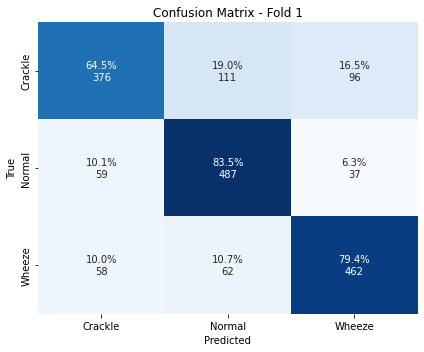

              precision    recall  f1-score   support

     Crackle       0.76      0.64      0.70       583
      Normal       0.74      0.84      0.78       583
      Wheeze       0.78      0.79      0.79       582

    accuracy                           0.76      1748
   macro avg       0.76      0.76      0.76      1748
weighted avg       0.76      0.76      0.76      1748


Fold 2


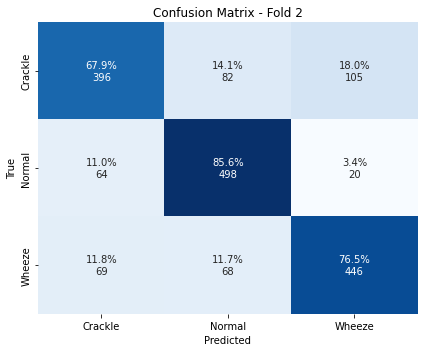

              precision    recall  f1-score   support

     Crackle       0.75      0.68      0.71       583
      Normal       0.77      0.86      0.81       582
      Wheeze       0.78      0.77      0.77       583

    accuracy                           0.77      1748
   macro avg       0.77      0.77      0.76      1748
weighted avg       0.77      0.77      0.76      1748


Fold 3


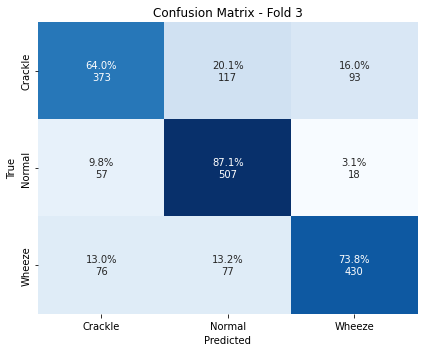

              precision    recall  f1-score   support

     Crackle       0.74      0.64      0.69       583
      Normal       0.72      0.87      0.79       582
      Wheeze       0.79      0.74      0.77       583

    accuracy                           0.75      1748
   macro avg       0.75      0.75      0.75      1748
weighted avg       0.75      0.75      0.75      1748


Fold 4


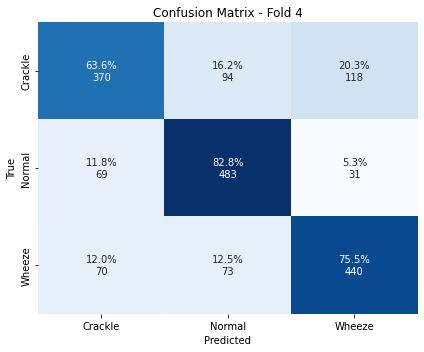

              precision    recall  f1-score   support

     Crackle       0.73      0.64      0.68       582
      Normal       0.74      0.83      0.78       583
      Wheeze       0.75      0.75      0.75       583

    accuracy                           0.74      1748
   macro avg       0.74      0.74      0.74      1748
weighted avg       0.74      0.74      0.74      1748


Fold 5


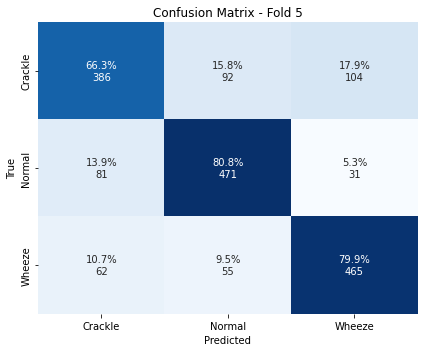

              precision    recall  f1-score   support

     Crackle       0.73      0.66      0.69       582
      Normal       0.76      0.81      0.78       583
      Wheeze       0.78      0.80      0.79       582

    accuracy                           0.76      1747
   macro avg       0.76      0.76      0.76      1747
weighted avg       0.76      0.76      0.76      1747



In [ ]:
from statistical_models.xgboost import train

param_dict = {"n_estimators": 200, "max_depth": 5, "learning_rate": 1}
xgb_model = train(X_train, y_train, classes, param_dict)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.71      0.61      0.66       373
      Normal       0.75      0.84      0.79       729
      Wheeze       0.64      0.51      0.57       177

    accuracy                           0.73      1279
   macro avg       0.70      0.65      0.67      1279
weighted avg       0.72      0.73      0.72      1279



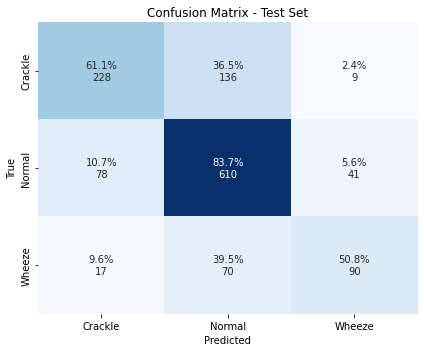

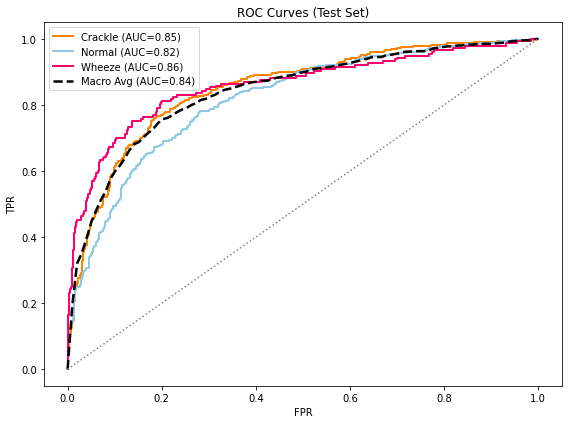

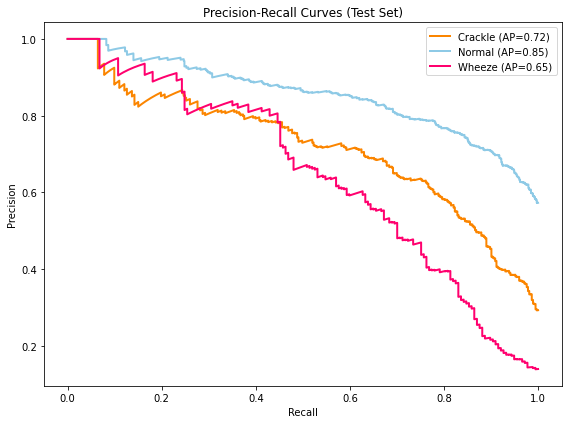

In [14]:
from statistical_models.evaluate import evaluate_model

xgb_metrics_df = evaluate_model(X_test, y_test, classes, xgb_model)

In [15]:
xgb_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.611260,0.895143,0.705882,0.848326,0.529767,0.753202
1,Normal,0.836763,0.625455,0.747549,0.742981,0.476163,0.731109
2,Wheeze,0.508475,0.954628,0.642857,0.923617,0.512187,0.731551


### **WITH DOMAIN ADAPTATION**

#### **1. CLASS SPECIFIC SPECTRUM CORRECTION**

#### **k-NN**


Fold 1


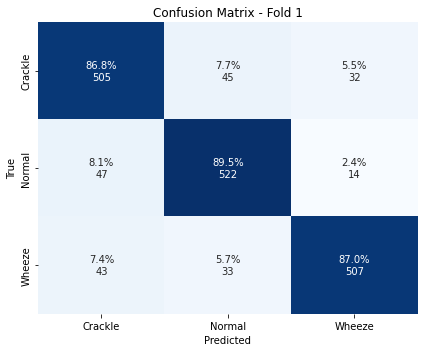

              precision    recall  f1-score   support

     Crackle       0.85      0.87      0.86       582
      Normal       0.87      0.90      0.88       583
      Wheeze       0.92      0.87      0.89       583

    accuracy                           0.88      1748
   macro avg       0.88      0.88      0.88      1748
weighted avg       0.88      0.88      0.88      1748


Fold 2


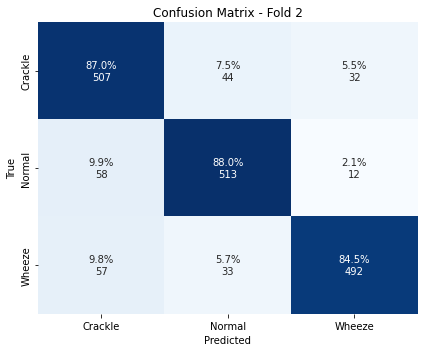

              precision    recall  f1-score   support

     Crackle       0.82      0.87      0.84       583
      Normal       0.87      0.88      0.87       583
      Wheeze       0.92      0.85      0.88       582

    accuracy                           0.86      1748
   macro avg       0.87      0.86      0.87      1748
weighted avg       0.87      0.86      0.87      1748


Fold 3


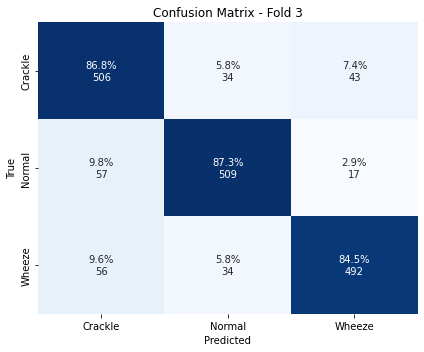

              precision    recall  f1-score   support

     Crackle       0.82      0.87      0.84       583
      Normal       0.88      0.87      0.88       583
      Wheeze       0.89      0.85      0.87       582

    accuracy                           0.86      1748
   macro avg       0.86      0.86      0.86      1748
weighted avg       0.86      0.86      0.86      1748


Fold 4


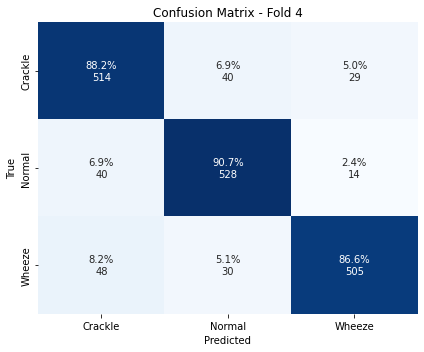

              precision    recall  f1-score   support

     Crackle       0.85      0.88      0.87       583
      Normal       0.88      0.91      0.89       582
      Wheeze       0.92      0.87      0.89       583

    accuracy                           0.89      1748
   macro avg       0.89      0.89      0.89      1748
weighted avg       0.89      0.89      0.89      1748


Fold 5


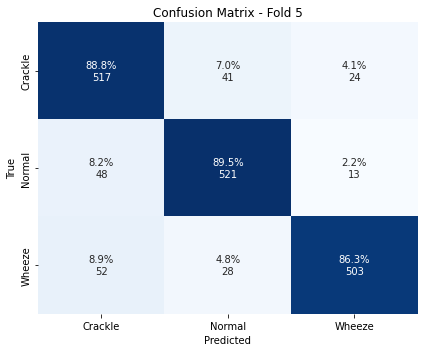

              precision    recall  f1-score   support

     Crackle       0.84      0.89      0.86       582
      Normal       0.88      0.90      0.89       582
      Wheeze       0.93      0.86      0.90       583

    accuracy                           0.88      1747
   macro avg       0.88      0.88      0.88      1747
weighted avg       0.88      0.88      0.88      1747



In [72]:
from statistical_models.knn import *

X_train = np.load("training_features_sc.npy")
y_train = np.load("training_labels_sc.npy")
X_test = np.load("test_features_sc.npy")
y_test = np.load("test_labels_sc.npy")

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
classes = le.classes_

# Apply MinMax Scaling 
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training
knn_model = train(X_train, y_train, classes, n_neighbors=3)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.79      0.84      0.82       373
      Normal       0.89      0.90      0.89       729
      Wheeze       0.87      0.72      0.79       177

    accuracy                           0.86      1279
   macro avg       0.85      0.82      0.83      1279
weighted avg       0.86      0.86      0.86      1279



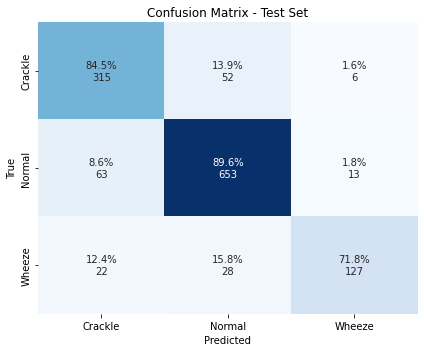

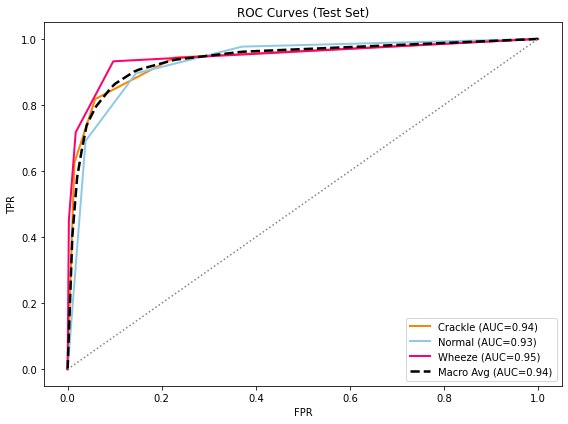

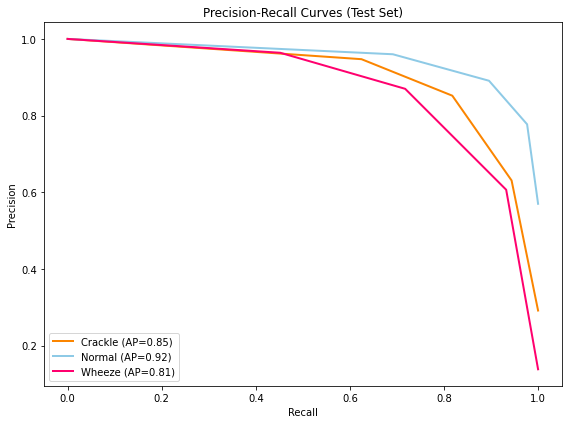

In [73]:
from statistical_models.evaluate import evaluate_model

knn_sc_metrics_df = evaluate_model(X_test, y_test, classes, knn_model)

In [74]:
knn_sc_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.844504,0.906181,0.787500,0.934016,0.735956,0.875343
1,Normal,0.895748,0.854545,0.890859,0.860806,0.750979,0.875147
2,Wheeze,0.717514,0.982759,0.869863,0.955869,0.760420,0.850136


#### **Non-Linear SVM (rbf kernel)**


Fold 1


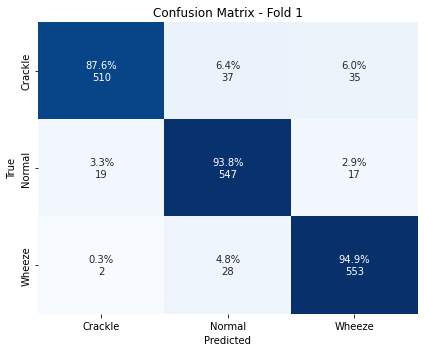

              precision    recall  f1-score   support

     Crackle       0.96      0.88      0.92       582
      Normal       0.89      0.94      0.92       583
      Wheeze       0.91      0.95      0.93       583

    accuracy                           0.92      1748
   macro avg       0.92      0.92      0.92      1748
weighted avg       0.92      0.92      0.92      1748


Fold 2


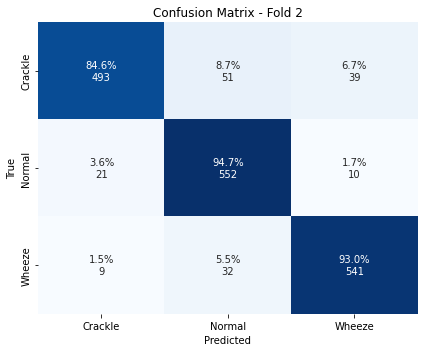

              precision    recall  f1-score   support

     Crackle       0.94      0.85      0.89       583
      Normal       0.87      0.95      0.91       583
      Wheeze       0.92      0.93      0.92       582

    accuracy                           0.91      1748
   macro avg       0.91      0.91      0.91      1748
weighted avg       0.91      0.91      0.91      1748


Fold 3


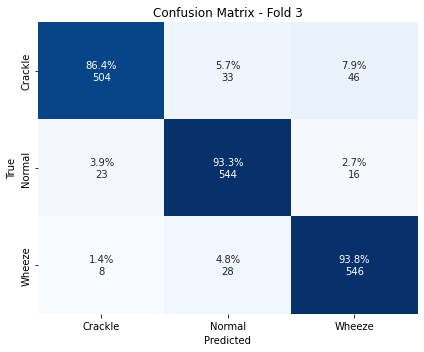

              precision    recall  f1-score   support

     Crackle       0.94      0.86      0.90       583
      Normal       0.90      0.93      0.92       583
      Wheeze       0.90      0.94      0.92       582

    accuracy                           0.91      1748
   macro avg       0.91      0.91      0.91      1748
weighted avg       0.91      0.91      0.91      1748


Fold 4


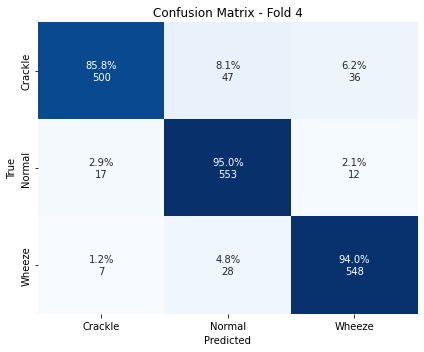

              precision    recall  f1-score   support

     Crackle       0.95      0.86      0.90       583
      Normal       0.88      0.95      0.91       582
      Wheeze       0.92      0.94      0.93       583

    accuracy                           0.92      1748
   macro avg       0.92      0.92      0.92      1748
weighted avg       0.92      0.92      0.92      1748


Fold 5


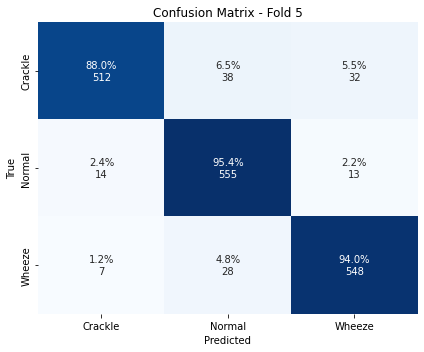

              precision    recall  f1-score   support

     Crackle       0.96      0.88      0.92       582
      Normal       0.89      0.95      0.92       582
      Wheeze       0.92      0.94      0.93       583

    accuracy                           0.92      1747
   macro avg       0.93      0.92      0.92      1747
weighted avg       0.93      0.92      0.92      1747



In [26]:
from statistical_models.non_linear_svm import *

C = grid.best_params_["C"]
gamma = grid.best_params_["gamma"]

svm_model = train(X_train, y_train, classes, n_splits=5, C=C, gamma=gamma)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.90      0.84      0.87       373
      Normal       0.89      0.94      0.91       729
      Wheeze       0.88      0.80      0.83       177

    accuracy                           0.89      1279
   macro avg       0.89      0.86      0.87      1279
weighted avg       0.89      0.89      0.89      1279



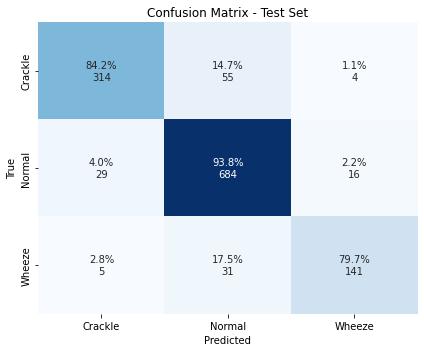

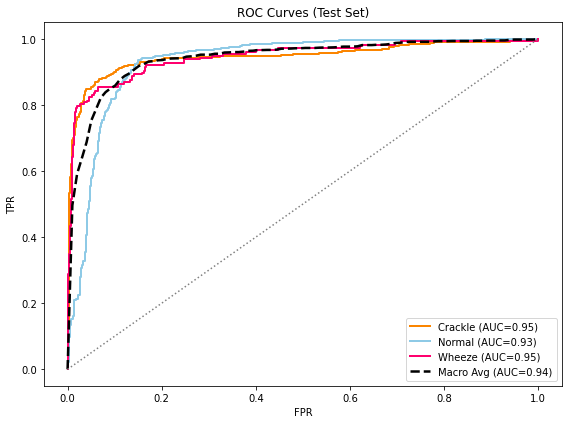

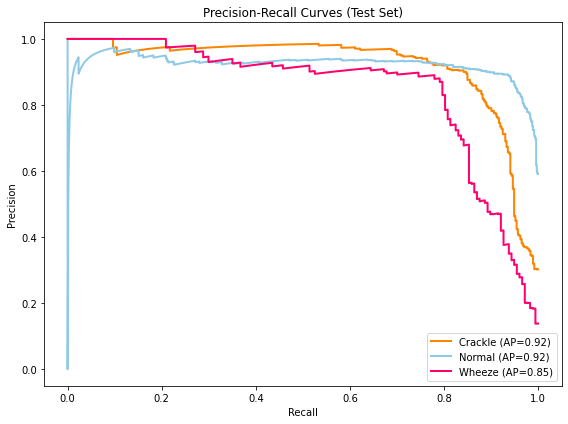

In [27]:
from statistical_models.evaluate import evaluate_model

svm_sc_metrics_df = evaluate_model(X_test, y_test, classes, svm_model)

In [28]:
svm_sc_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.841823,0.962472,0.902299,0.936627,0.821428,0.902148
1,Normal,0.938272,0.843636,0.888312,0.911591,0.790854,0.890954
2,Wheeze,0.796610,0.981851,0.875776,0.967800,0.810365,0.889231


#### **Random Forest**


Fold 1


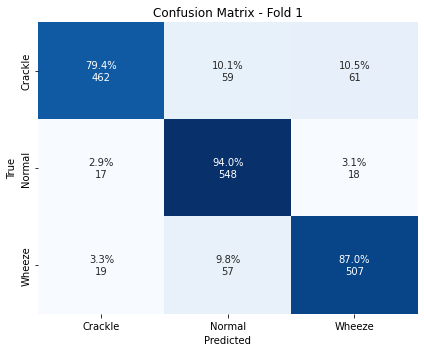

              precision    recall  f1-score   support

     Crackle       0.93      0.79      0.86       582
      Normal       0.83      0.94      0.88       583
      Wheeze       0.87      0.87      0.87       583

    accuracy                           0.87      1748
   macro avg       0.87      0.87      0.87      1748
weighted avg       0.87      0.87      0.87      1748


Fold 2


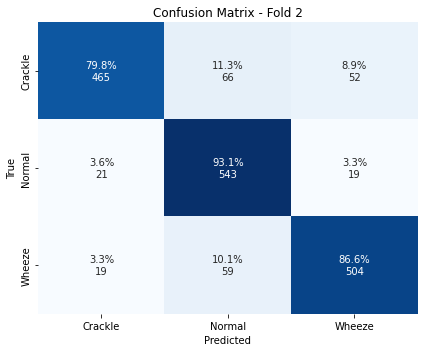

              precision    recall  f1-score   support

     Crackle       0.92      0.80      0.85       583
      Normal       0.81      0.93      0.87       583
      Wheeze       0.88      0.87      0.87       582

    accuracy                           0.86      1748
   macro avg       0.87      0.86      0.86      1748
weighted avg       0.87      0.86      0.86      1748


Fold 3


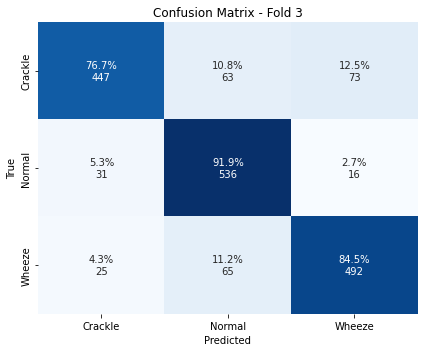

              precision    recall  f1-score   support

     Crackle       0.89      0.77      0.82       583
      Normal       0.81      0.92      0.86       583
      Wheeze       0.85      0.85      0.85       582

    accuracy                           0.84      1748
   macro avg       0.85      0.84      0.84      1748
weighted avg       0.85      0.84      0.84      1748


Fold 4


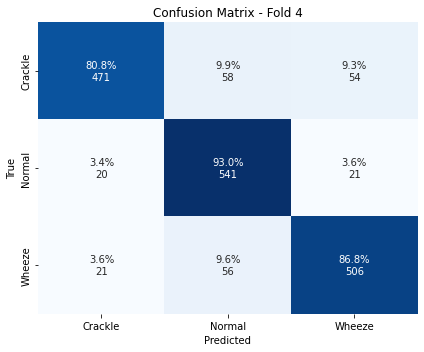

              precision    recall  f1-score   support

     Crackle       0.92      0.81      0.86       583
      Normal       0.83      0.93      0.87       582
      Wheeze       0.87      0.87      0.87       583

    accuracy                           0.87      1748
   macro avg       0.87      0.87      0.87      1748
weighted avg       0.87      0.87      0.87      1748


Fold 5


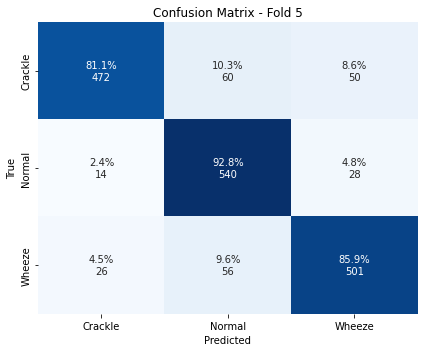

              precision    recall  f1-score   support

     Crackle       0.92      0.81      0.86       582
      Normal       0.82      0.93      0.87       582
      Wheeze       0.87      0.86      0.86       583

    accuracy                           0.87      1747
   macro avg       0.87      0.87      0.87      1747
weighted avg       0.87      0.87      0.87      1747



In [19]:
from statistical_models.random_forest import *

# Train
best_params = {
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 2
}

rf_model = train(X_train, y_train, classes, best_params)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.89      0.74      0.81       373
      Normal       0.83      0.94      0.88       729
      Wheeze       0.78      0.63      0.70       177

    accuracy                           0.84      1279
   macro avg       0.83      0.77      0.79      1279
weighted avg       0.84      0.84      0.83      1279



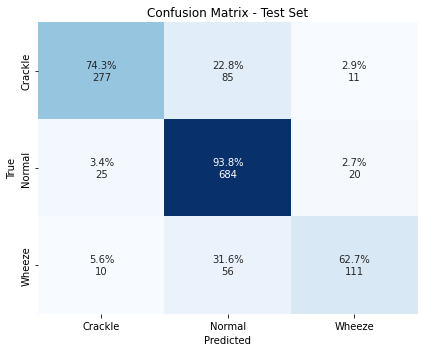

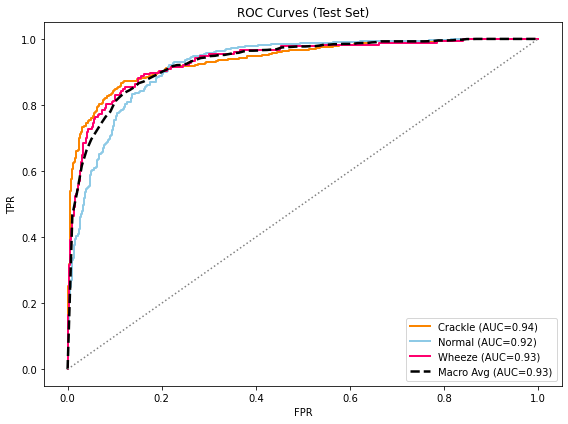

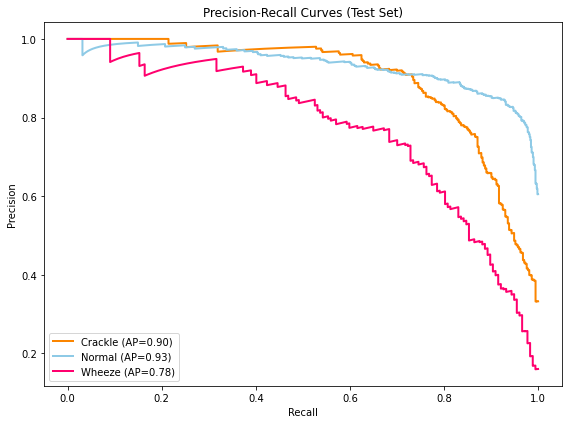

In [20]:
from statistical_models.evaluate import evaluate_model

rf_sc_metrics_df = evaluate_model(X_test, y_test, classes, rf_model)

In [21]:
rf_sc_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.742627,0.961369,0.887821,0.900724,0.745072,0.851998
1,Normal,0.938272,0.743636,0.829091,0.900881,0.705531,0.840954
2,Wheeze,0.627119,0.971869,0.781690,0.941953,0.658372,0.799494


#### **XGBoost**


Fold 1


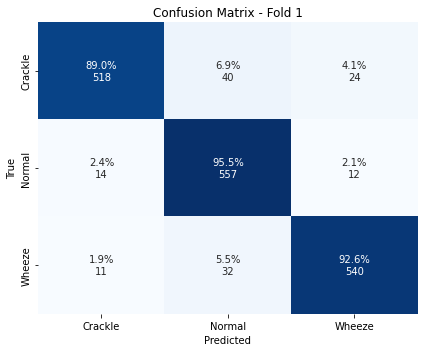

              precision    recall  f1-score   support

     Crackle       0.95      0.89      0.92       582
      Normal       0.89      0.96      0.92       583
      Wheeze       0.94      0.93      0.93       583

    accuracy                           0.92      1748
   macro avg       0.93      0.92      0.92      1748
weighted avg       0.93      0.92      0.92      1748


Fold 2


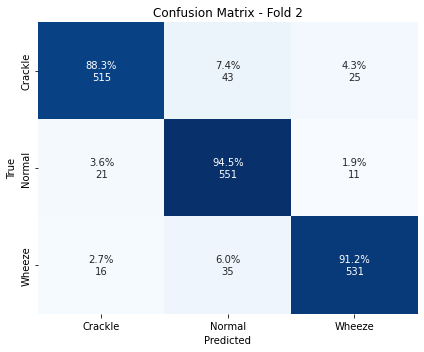

              precision    recall  f1-score   support

     Crackle       0.93      0.88      0.91       583
      Normal       0.88      0.95      0.91       583
      Wheeze       0.94      0.91      0.92       582

    accuracy                           0.91      1748
   macro avg       0.92      0.91      0.91      1748
weighted avg       0.92      0.91      0.91      1748


Fold 3


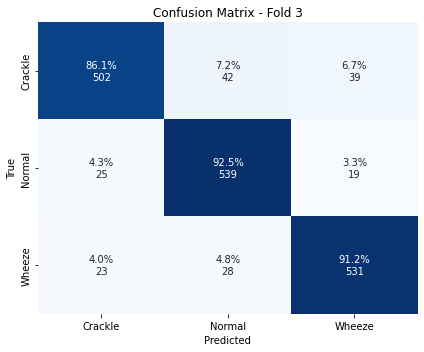

              precision    recall  f1-score   support

     Crackle       0.91      0.86      0.89       583
      Normal       0.89      0.92      0.90       583
      Wheeze       0.90      0.91      0.91       582

    accuracy                           0.90      1748
   macro avg       0.90      0.90      0.90      1748
weighted avg       0.90      0.90      0.90      1748


Fold 4


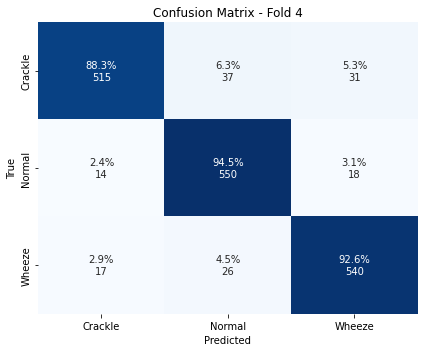

              precision    recall  f1-score   support

     Crackle       0.94      0.88      0.91       583
      Normal       0.90      0.95      0.92       582
      Wheeze       0.92      0.93      0.92       583

    accuracy                           0.92      1748
   macro avg       0.92      0.92      0.92      1748
weighted avg       0.92      0.92      0.92      1748


Fold 5


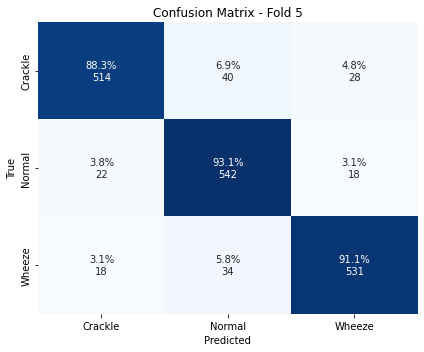

              precision    recall  f1-score   support

     Crackle       0.93      0.88      0.90       582
      Normal       0.88      0.93      0.90       582
      Wheeze       0.92      0.91      0.92       583

    accuracy                           0.91      1747
   macro avg       0.91      0.91      0.91      1747
weighted avg       0.91      0.91      0.91      1747



In [22]:
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def train(X, y, classes, param_dict, n_splits=5):
    """
    Perform cross-validation training with calibrated XGBoost, showing CM + report per fold.

    Args:
        X (np.ndarray): Feature matrix.
        y (np.ndarray): Encoded labels.
        classes (list): Class names.
        param_dict (dict): XGBoost hyperparameters (e.g., n_estimators, max_depth, learning_rate).
        n_splits (int): Number of folds.

    Returns:
        CalibratedClassifierCV: Final trained model on full data.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        print(f"\nFold {fold}")
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        base_xgb = XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            use_label_encoder=False,
            random_state=42,
            n_jobs=-1,
            **param_dict
        )
        clf = CalibratedClassifierCV(base_xgb, method="sigmoid", cv=3)
        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_val)
        cm = confusion_matrix(y_val, y_pred)
        cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
        annot = np.empty_like(cm).astype(str)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f"{cm_percent[i,j]:.1f}%\n{cm[i,j]}"

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
                    xticklabels=classes, yticklabels=classes, cbar=False)
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix - Fold {fold}")
        plt.tight_layout()
        plt.show()

        print(classification_report(y_val, y_pred, target_names=classes))

    # Train final model on full data
    final_xgb = XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1,
        **param_dict
    )
    final_clf = CalibratedClassifierCV(final_xgb, method="sigmoid", cv=3)
    final_clf.fit(X, y)

    return final_clf

param_dict = {"n_estimators": 200, "max_depth": 5, "learning_rate": 1}
xgb_model = train(X_train, y_train, classes, param_dict)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.90      0.85      0.87       373
      Normal       0.89      0.94      0.91       729
      Wheeze       0.87      0.77      0.81       177

    accuracy                           0.89      1279
   macro avg       0.88      0.85      0.87      1279
weighted avg       0.89      0.89      0.89      1279



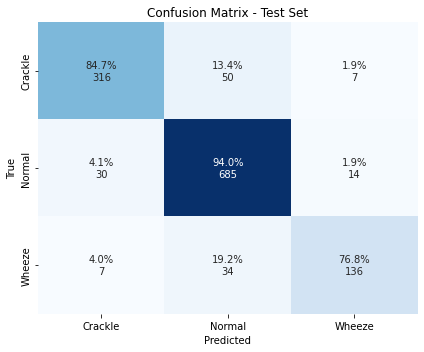

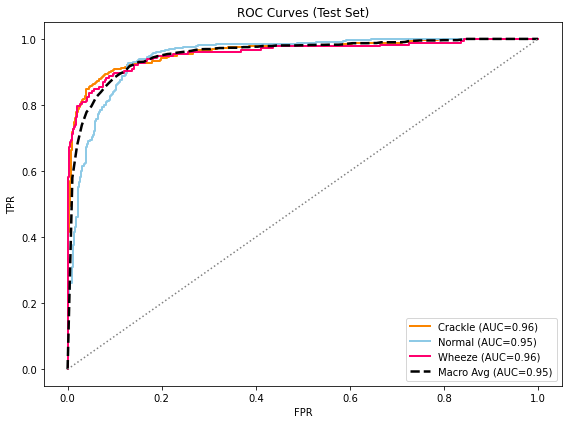

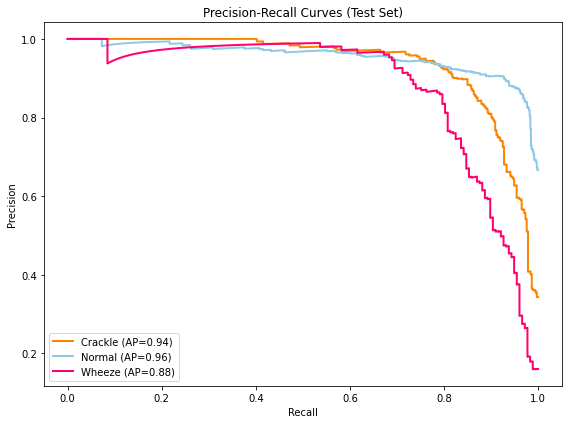

In [23]:
from statistical_models.evaluate import evaluate_model

xgb_sc_metrics_df = evaluate_model(X_test, y_test, classes, xgb_model)

In [24]:
xgb_sc_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.847185,0.959161,0.895184,0.938445,0.819874,0.903173
1,Normal,0.939643,0.847273,0.890767,0.913725,0.795656,0.893458
2,Wheeze,0.768362,0.980944,0.866242,0.963458,0.788479,0.874653


### **2. SPECTRUM NORMALIZATION**


Fold 1


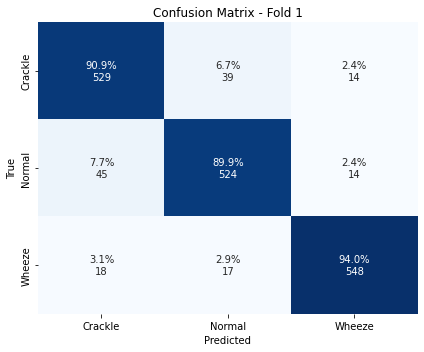

              precision    recall  f1-score   support

     Crackle       0.89      0.91      0.90       582
      Normal       0.90      0.90      0.90       583
      Wheeze       0.95      0.94      0.95       583

    accuracy                           0.92      1748
   macro avg       0.92      0.92      0.92      1748
weighted avg       0.92      0.92      0.92      1748


Fold 2


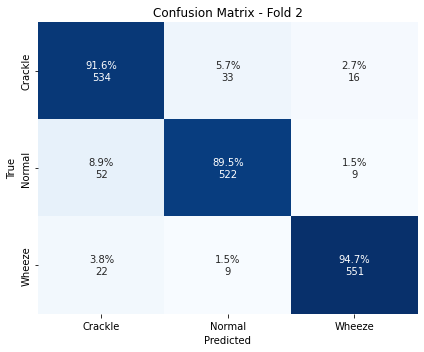

              precision    recall  f1-score   support

     Crackle       0.88      0.92      0.90       583
      Normal       0.93      0.90      0.91       583
      Wheeze       0.96      0.95      0.95       582

    accuracy                           0.92      1748
   macro avg       0.92      0.92      0.92      1748
weighted avg       0.92      0.92      0.92      1748


Fold 3


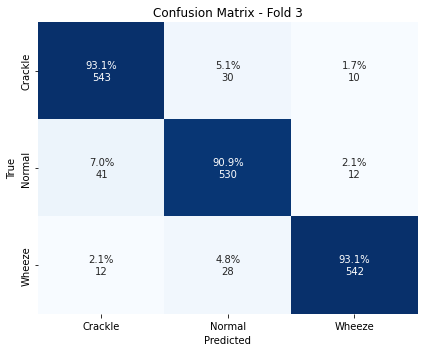

              precision    recall  f1-score   support

     Crackle       0.91      0.93      0.92       583
      Normal       0.90      0.91      0.91       583
      Wheeze       0.96      0.93      0.95       582

    accuracy                           0.92      1748
   macro avg       0.92      0.92      0.92      1748
weighted avg       0.92      0.92      0.92      1748


Fold 4


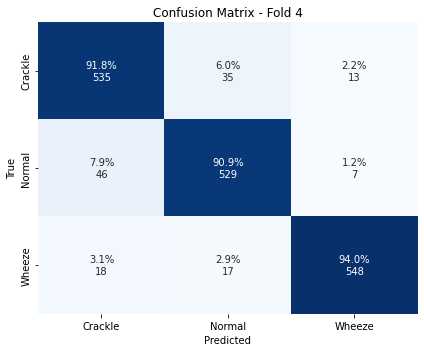

              precision    recall  f1-score   support

     Crackle       0.89      0.92      0.91       583
      Normal       0.91      0.91      0.91       582
      Wheeze       0.96      0.94      0.95       583

    accuracy                           0.92      1748
   macro avg       0.92      0.92      0.92      1748
weighted avg       0.92      0.92      0.92      1748


Fold 5


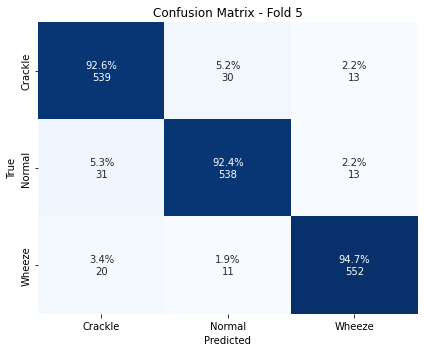

              precision    recall  f1-score   support

     Crackle       0.91      0.93      0.92       582
      Normal       0.93      0.92      0.93       582
      Wheeze       0.96      0.95      0.95       583

    accuracy                           0.93      1747
   macro avg       0.93      0.93      0.93      1747
weighted avg       0.93      0.93      0.93      1747



In [75]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from statistical_models.knn import *

X_train = np.load("training_features_std.npy")
y_train = np.load("training_labels_std.npy")
X_test = np.load("test_features_std.npy")
y_test = np.load("test_labels_std.npy")

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
classes = le.classes_

# Apply MinMax Scaling 
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training
knn_model = train(X_train, y_train, classes, n_neighbors=3)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.83      0.89      0.86       373
      Normal       0.93      0.91      0.92       729
      Wheeze       0.90      0.86      0.88       177

    accuracy                           0.90      1279
   macro avg       0.89      0.88      0.89      1279
weighted avg       0.90      0.90      0.90      1279



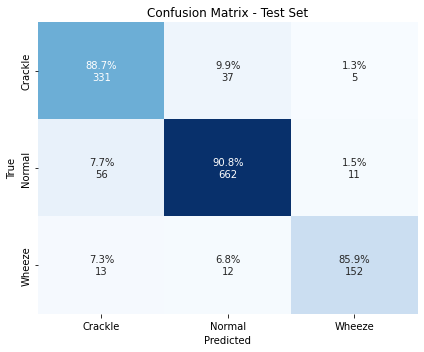

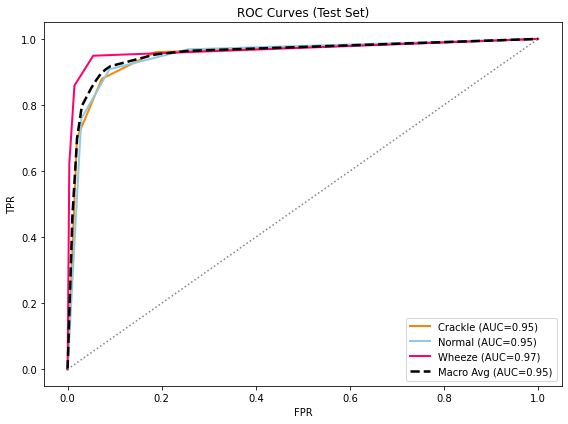

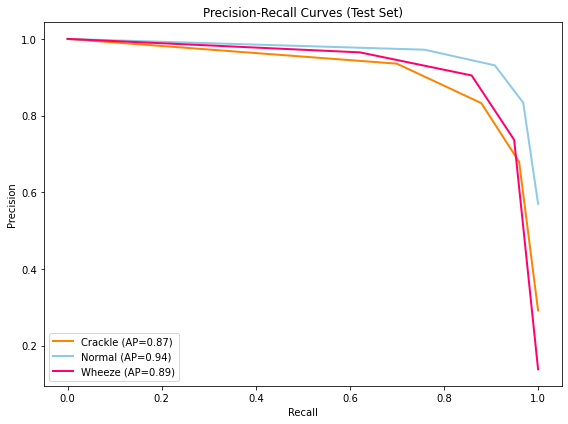

In [76]:
knn_norm_metrics_df = evaluate_model(X_test, y_test, classes, knn_model)

#### **Non-Linear SVM (rbf kernel)**


Fold 1


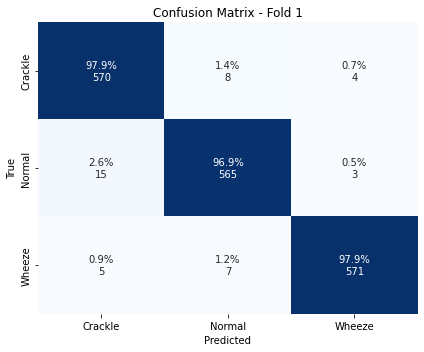

              precision    recall  f1-score   support

     Crackle       0.97      0.98      0.97       582
      Normal       0.97      0.97      0.97       583
      Wheeze       0.99      0.98      0.98       583

    accuracy                           0.98      1748
   macro avg       0.98      0.98      0.98      1748
weighted avg       0.98      0.98      0.98      1748


Fold 2


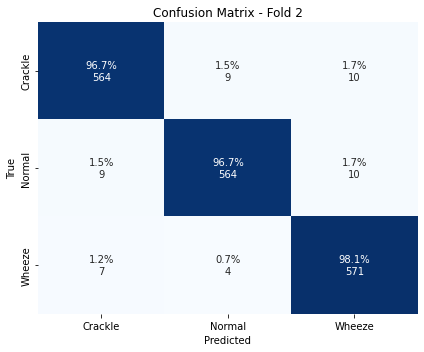

              precision    recall  f1-score   support

     Crackle       0.97      0.97      0.97       583
      Normal       0.98      0.97      0.97       583
      Wheeze       0.97      0.98      0.97       582

    accuracy                           0.97      1748
   macro avg       0.97      0.97      0.97      1748
weighted avg       0.97      0.97      0.97      1748


Fold 3


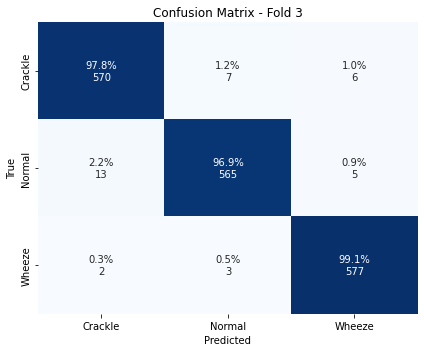

              precision    recall  f1-score   support

     Crackle       0.97      0.98      0.98       583
      Normal       0.98      0.97      0.98       583
      Wheeze       0.98      0.99      0.99       582

    accuracy                           0.98      1748
   macro avg       0.98      0.98      0.98      1748
weighted avg       0.98      0.98      0.98      1748


Fold 4


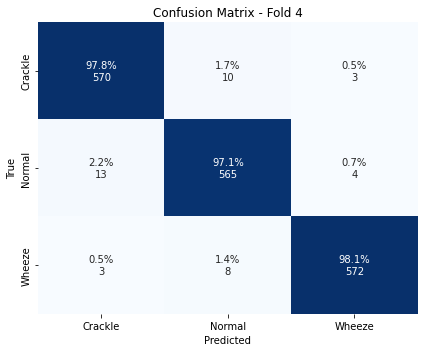

              precision    recall  f1-score   support

     Crackle       0.97      0.98      0.98       583
      Normal       0.97      0.97      0.97       582
      Wheeze       0.99      0.98      0.98       583

    accuracy                           0.98      1748
   macro avg       0.98      0.98      0.98      1748
weighted avg       0.98      0.98      0.98      1748


Fold 5


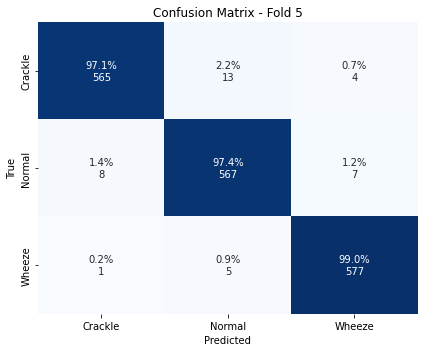

              precision    recall  f1-score   support

     Crackle       0.98      0.97      0.98       582
      Normal       0.97      0.97      0.97       582
      Wheeze       0.98      0.99      0.99       583

    accuracy                           0.98      1747
   macro avg       0.98      0.98      0.98      1747
weighted avg       0.98      0.98      0.98      1747



In [44]:
from statistical_models.non_linear_svm import *

C = grid.best_params_["C"]
gamma = grid.best_params_["gamma"]

svm_model = train(X_train, y_train, classes, n_splits=5, C=C, gamma=gamma)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.94      0.96      0.95       373
      Normal       0.98      0.96      0.97       729
      Wheeze       0.96      0.96      0.96       177

    accuracy                           0.96      1279
   macro avg       0.96      0.96      0.96      1279
weighted avg       0.96      0.96      0.96      1279



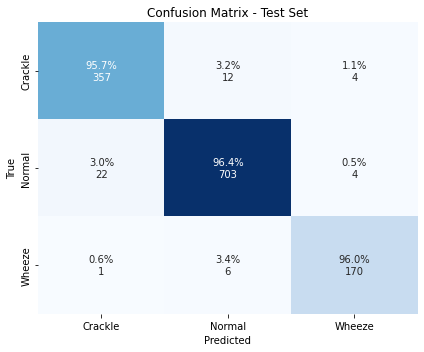

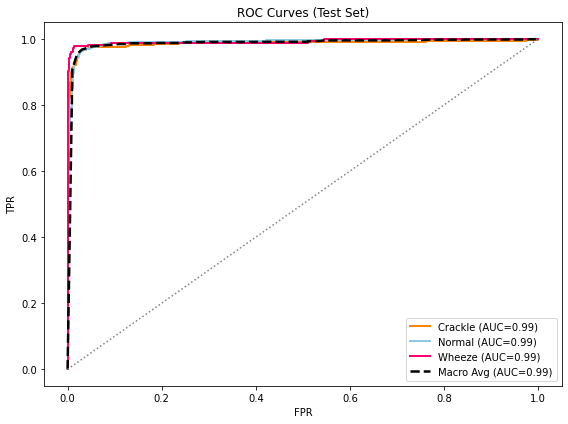

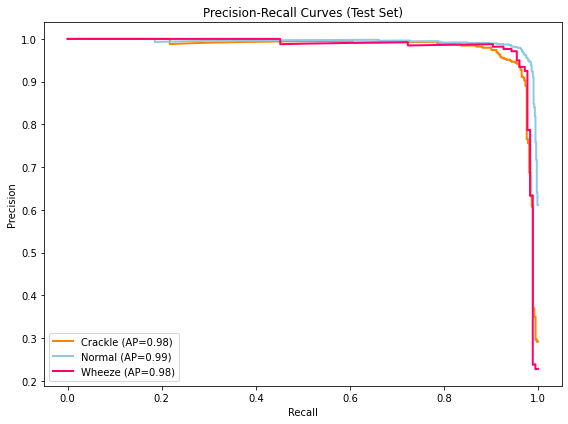

In [45]:
svm_norm_metrics_df = evaluate_model(X_test, y_test, classes, svm_model)

In [46]:
svm_norm_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.957105,0.974614,0.939474,0.982202,0.926684,0.965859
1,Normal,0.964335,0.967273,0.975035,0.953405,0.930022,0.965804
2,Wheeze,0.960452,0.992740,0.955056,0.993642,0.950943,0.976596


#### **Random Forest**


Fold 1


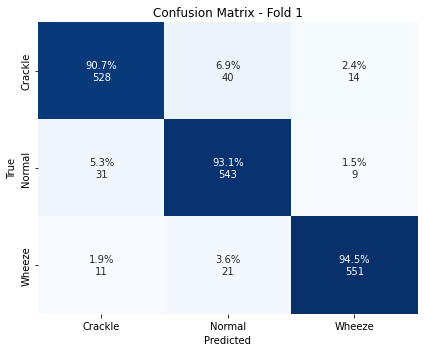

              precision    recall  f1-score   support

     Crackle       0.93      0.91      0.92       582
      Normal       0.90      0.93      0.91       583
      Wheeze       0.96      0.95      0.95       583

    accuracy                           0.93      1748
   macro avg       0.93      0.93      0.93      1748
weighted avg       0.93      0.93      0.93      1748


Fold 2


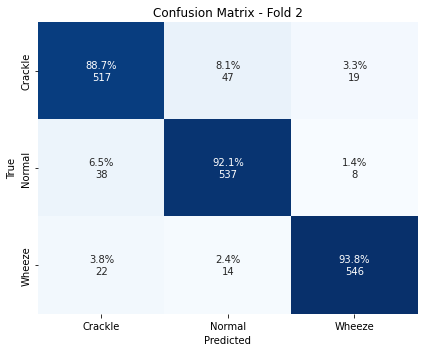

              precision    recall  f1-score   support

     Crackle       0.90      0.89      0.89       583
      Normal       0.90      0.92      0.91       583
      Wheeze       0.95      0.94      0.95       582

    accuracy                           0.92      1748
   macro avg       0.92      0.92      0.92      1748
weighted avg       0.92      0.92      0.92      1748


Fold 3


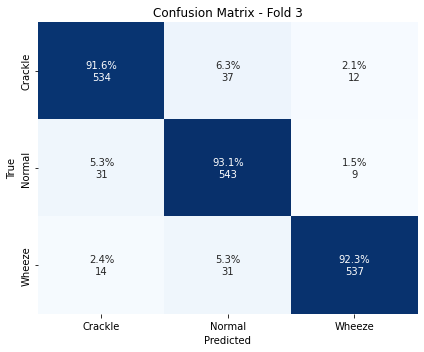

              precision    recall  f1-score   support

     Crackle       0.92      0.92      0.92       583
      Normal       0.89      0.93      0.91       583
      Wheeze       0.96      0.92      0.94       582

    accuracy                           0.92      1748
   macro avg       0.92      0.92      0.92      1748
weighted avg       0.92      0.92      0.92      1748


Fold 4


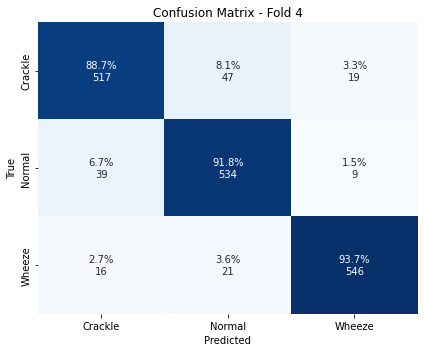

              precision    recall  f1-score   support

     Crackle       0.90      0.89      0.90       583
      Normal       0.89      0.92      0.90       582
      Wheeze       0.95      0.94      0.94       583

    accuracy                           0.91      1748
   macro avg       0.91      0.91      0.91      1748
weighted avg       0.91      0.91      0.91      1748


Fold 5


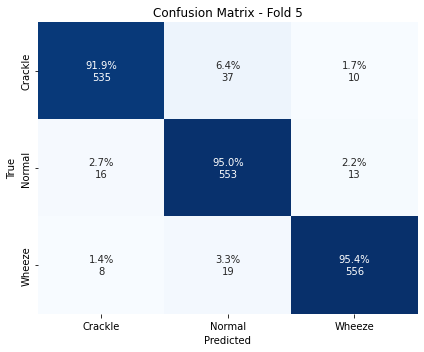

              precision    recall  f1-score   support

     Crackle       0.96      0.92      0.94       582
      Normal       0.91      0.95      0.93       582
      Wheeze       0.96      0.95      0.96       583

    accuracy                           0.94      1747
   macro avg       0.94      0.94      0.94      1747
weighted avg       0.94      0.94      0.94      1747



In [37]:
from statistical_models.random_forest import *

# Train
best_params = {
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 2
}

rf_model = train(X_train, y_train, classes, best_params)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.85      0.85      0.85       373
      Normal       0.92      0.93      0.92       729
      Wheeze       0.87      0.86      0.87       177

    accuracy                           0.89      1279
   macro avg       0.88      0.88      0.88      1279
weighted avg       0.89      0.89      0.89      1279



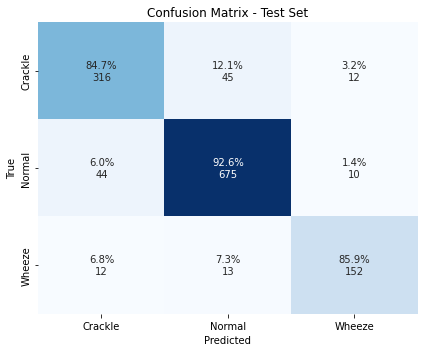

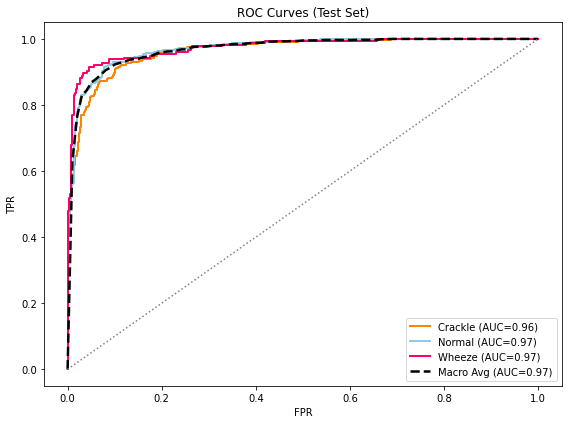

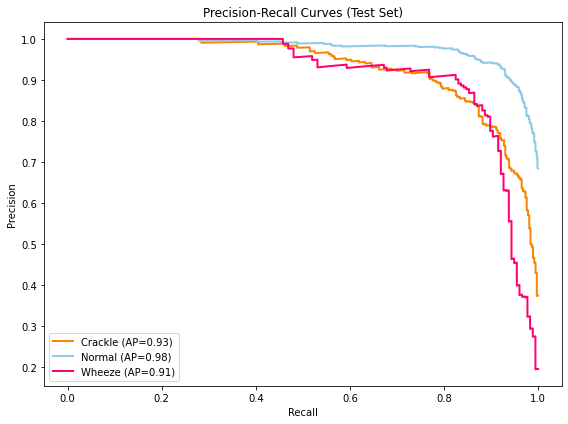

In [ ]:
rf_norm_metrics_df = evaluate_model(X_test, y_test, classes, rf_model)

In [ ]:
rf_norm_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.847185,0.938190,0.849462,0.937155,0.785996,0.892687
1,Normal,0.925926,0.894545,0.920873,0.901099,0.821221,0.910236
2,Wheeze,0.858757,0.980036,0.873563,0.977376,0.844844,0.919397


#### **XGBoost**


Fold 1


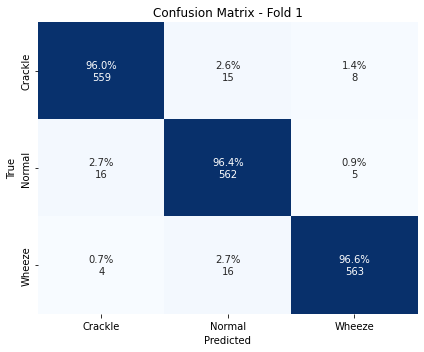

              precision    recall  f1-score   support

     Crackle       0.97      0.96      0.96       582
      Normal       0.95      0.96      0.96       583
      Wheeze       0.98      0.97      0.97       583

    accuracy                           0.96      1748
   macro avg       0.96      0.96      0.96      1748
weighted avg       0.96      0.96      0.96      1748


Fold 2


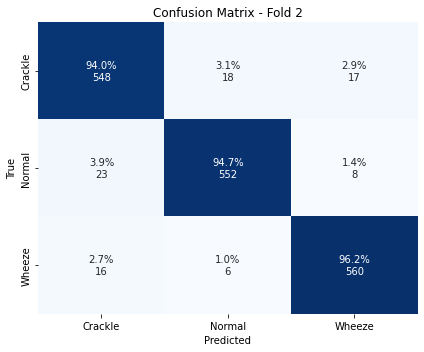

              precision    recall  f1-score   support

     Crackle       0.93      0.94      0.94       583
      Normal       0.96      0.95      0.95       583
      Wheeze       0.96      0.96      0.96       582

    accuracy                           0.95      1748
   macro avg       0.95      0.95      0.95      1748
weighted avg       0.95      0.95      0.95      1748


Fold 3


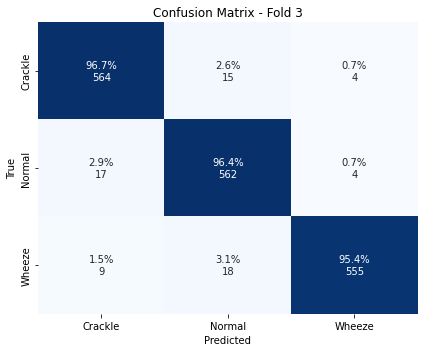

              precision    recall  f1-score   support

     Crackle       0.96      0.97      0.96       583
      Normal       0.94      0.96      0.95       583
      Wheeze       0.99      0.95      0.97       582

    accuracy                           0.96      1748
   macro avg       0.96      0.96      0.96      1748
weighted avg       0.96      0.96      0.96      1748


Fold 4


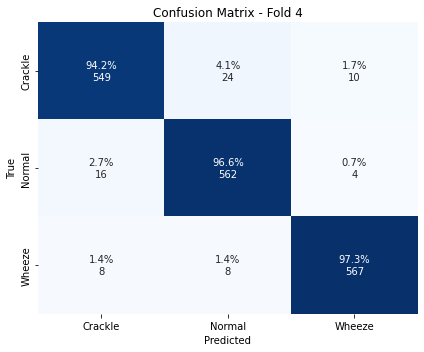

              precision    recall  f1-score   support

     Crackle       0.96      0.94      0.95       583
      Normal       0.95      0.97      0.96       582
      Wheeze       0.98      0.97      0.97       583

    accuracy                           0.96      1748
   macro avg       0.96      0.96      0.96      1748
weighted avg       0.96      0.96      0.96      1748


Fold 5


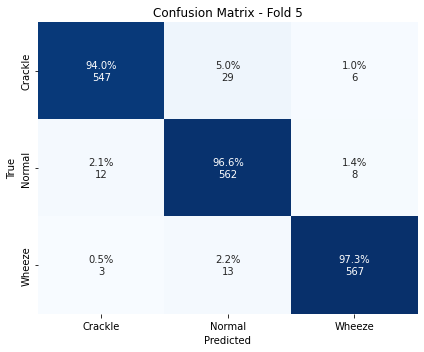

              precision    recall  f1-score   support

     Crackle       0.97      0.94      0.96       582
      Normal       0.93      0.97      0.95       582
      Wheeze       0.98      0.97      0.97       583

    accuracy                           0.96      1747
   macro avg       0.96      0.96      0.96      1747
weighted avg       0.96      0.96      0.96      1747



In [41]:
from statistical_models.xgboost import *

param_dict = {"n_estimators": 200, "max_depth": 5, "learning_rate": 1}
xgb_model = train(X_train, y_train, classes, param_dict)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.91      0.92      0.91       373
      Normal       0.95      0.96      0.95       729
      Wheeze       0.95      0.90      0.93       177

    accuracy                           0.94      1279
   macro avg       0.94      0.93      0.93      1279
weighted avg       0.94      0.94      0.94      1279



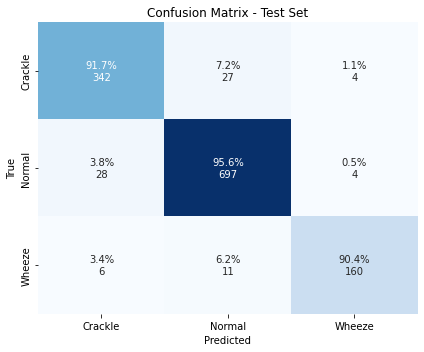

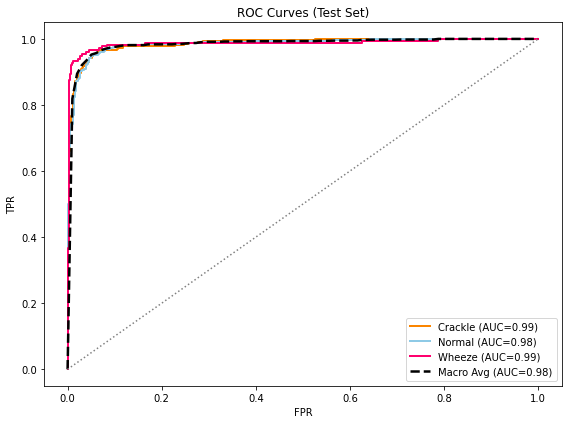

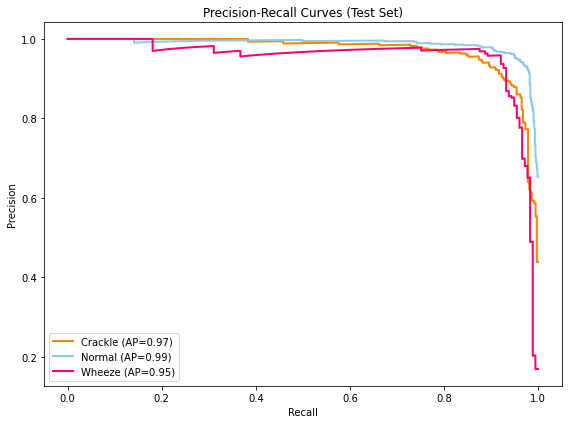

In [42]:
xgb_norm_metrics_df = evaluate_model(X_test, y_test, classes, xgb_model)

In [43]:
xgb_norm_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.916890,0.962472,0.909574,0.965670,0.877301,0.939681
1,Normal,0.956104,0.930909,0.948299,0.941176,0.888244,0.943507
2,Wheeze,0.903955,0.992740,0.952381,0.984698,0.916665,0.948348


### **3. CLASS SPECIFIC SPECTRAL WHITENING**

#### **k-NN**


Fold 1


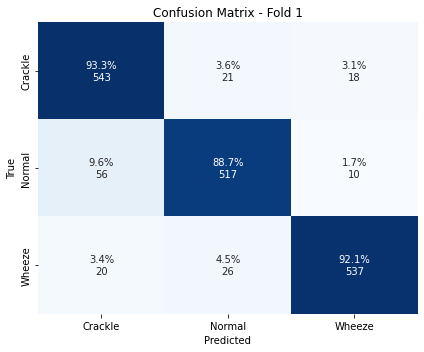

              precision    recall  f1-score   support

     Crackle       0.88      0.93      0.90       582
      Normal       0.92      0.89      0.90       583
      Wheeze       0.95      0.92      0.94       583

    accuracy                           0.91      1748
   macro avg       0.91      0.91      0.91      1748
weighted avg       0.91      0.91      0.91      1748


Fold 2


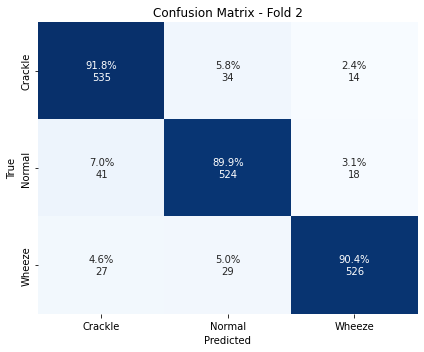

              precision    recall  f1-score   support

     Crackle       0.89      0.92      0.90       583
      Normal       0.89      0.90      0.90       583
      Wheeze       0.94      0.90      0.92       582

    accuracy                           0.91      1748
   macro avg       0.91      0.91      0.91      1748
weighted avg       0.91      0.91      0.91      1748


Fold 3


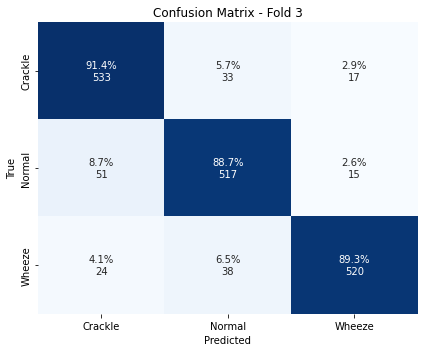

              precision    recall  f1-score   support

     Crackle       0.88      0.91      0.90       583
      Normal       0.88      0.89      0.88       583
      Wheeze       0.94      0.89      0.92       582

    accuracy                           0.90      1748
   macro avg       0.90      0.90      0.90      1748
weighted avg       0.90      0.90      0.90      1748


Fold 4


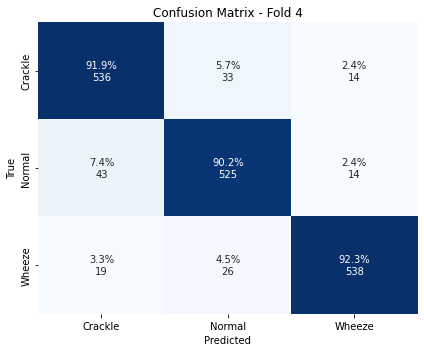

              precision    recall  f1-score   support

     Crackle       0.90      0.92      0.91       583
      Normal       0.90      0.90      0.90       582
      Wheeze       0.95      0.92      0.94       583

    accuracy                           0.91      1748
   macro avg       0.92      0.91      0.91      1748
weighted avg       0.92      0.91      0.91      1748


Fold 5


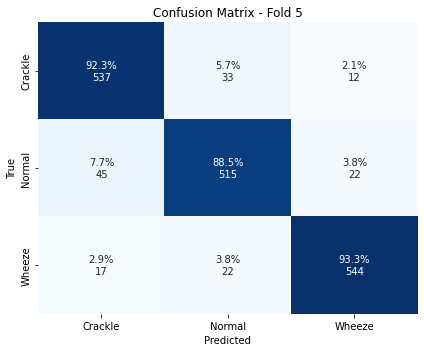

              precision    recall  f1-score   support

     Crackle       0.90      0.92      0.91       582
      Normal       0.90      0.88      0.89       582
      Wheeze       0.94      0.93      0.94       583

    accuracy                           0.91      1747
   macro avg       0.91      0.91      0.91      1747
weighted avg       0.91      0.91      0.91      1747



In [77]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from statistical_models.knn import *

X_train = np.load("training_features_whitened.npy")
y_train = np.load("training_labels_whitened.npy")
X_test = np.load("test_features_whitened.npy")
y_test = np.load("test_labels_whitened.npy")

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
classes = le.classes_

# Apply MinMax Scaling 
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training
knn_model = train(X_train, y_train, classes, n_neighbors=3)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.79      0.88      0.84       373
      Normal       0.90      0.89      0.89       729
      Wheeze       0.92      0.72      0.81       177

    accuracy                           0.87      1279
   macro avg       0.87      0.83      0.85      1279
weighted avg       0.87      0.87      0.87      1279



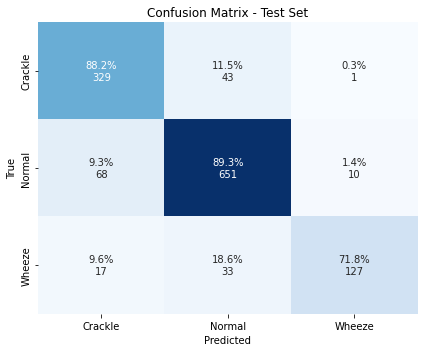

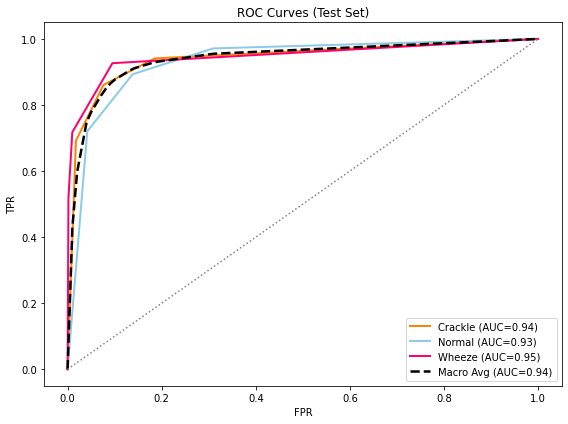

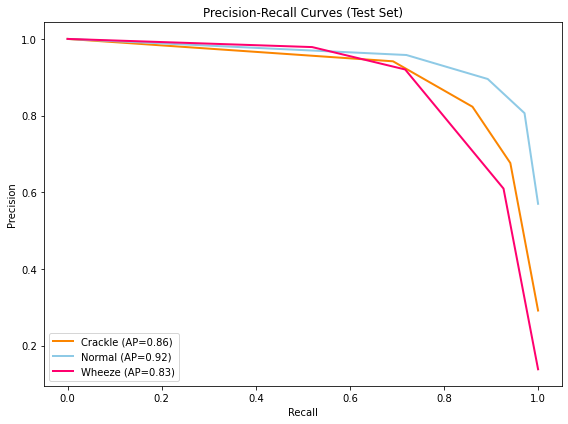

In [78]:
knn_whitening_metrics_df = evaluate_model(X_test, y_test, classes, knn_model)

In [79]:
knn_whitening_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.882038,0.906181,0.794686,0.949133,0.765697,0.894109
1,Normal,0.893004,0.861818,0.895461,0.858696,0.754489,0.877411
2,Wheeze,0.717514,0.990018,0.920290,0.956179,0.787483,0.853766


#### **Non-Linear SVM (rbf kernel)**


Fold 1


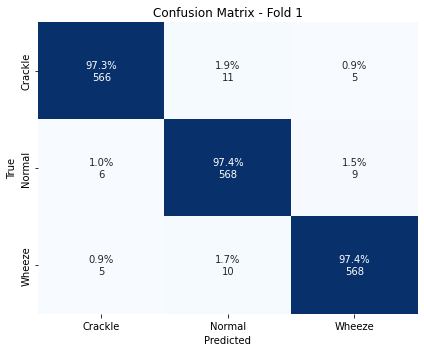

              precision    recall  f1-score   support

     Crackle       0.98      0.97      0.98       582
      Normal       0.96      0.97      0.97       583
      Wheeze       0.98      0.97      0.98       583

    accuracy                           0.97      1748
   macro avg       0.97      0.97      0.97      1748
weighted avg       0.97      0.97      0.97      1748


Fold 2


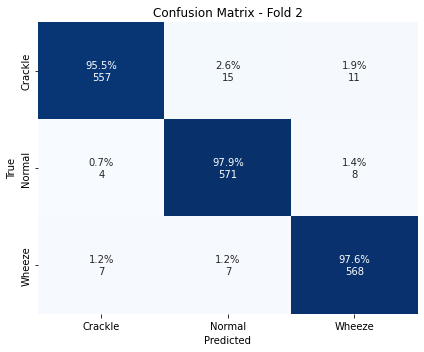

              precision    recall  f1-score   support

     Crackle       0.98      0.96      0.97       583
      Normal       0.96      0.98      0.97       583
      Wheeze       0.97      0.98      0.97       582

    accuracy                           0.97      1748
   macro avg       0.97      0.97      0.97      1748
weighted avg       0.97      0.97      0.97      1748


Fold 3


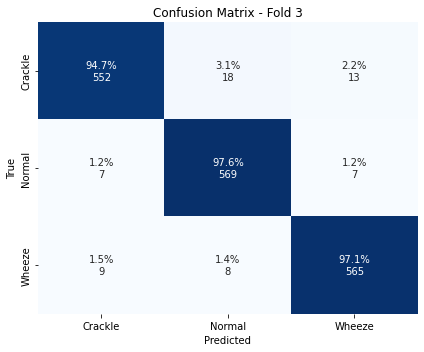

              precision    recall  f1-score   support

     Crackle       0.97      0.95      0.96       583
      Normal       0.96      0.98      0.97       583
      Wheeze       0.97      0.97      0.97       582

    accuracy                           0.96      1748
   macro avg       0.96      0.96      0.96      1748
weighted avg       0.96      0.96      0.96      1748


Fold 4


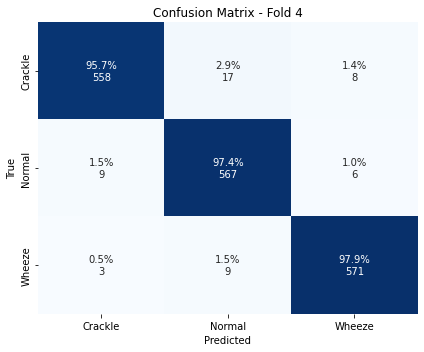

              precision    recall  f1-score   support

     Crackle       0.98      0.96      0.97       583
      Normal       0.96      0.97      0.97       582
      Wheeze       0.98      0.98      0.98       583

    accuracy                           0.97      1748
   macro avg       0.97      0.97      0.97      1748
weighted avg       0.97      0.97      0.97      1748


Fold 5


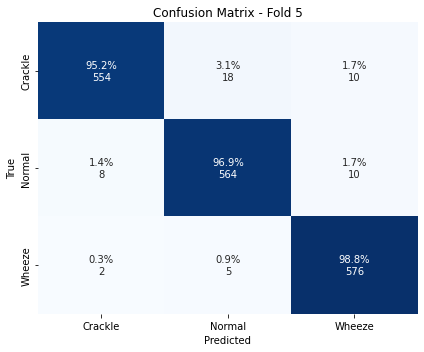

              precision    recall  f1-score   support

     Crackle       0.98      0.95      0.97       582
      Normal       0.96      0.97      0.96       582
      Wheeze       0.97      0.99      0.98       583

    accuracy                           0.97      1747
   macro avg       0.97      0.97      0.97      1747
weighted avg       0.97      0.97      0.97      1747



In [66]:
from statistical_models.non_linear_svm import *

C = grid.best_params_["C"]
gamma = grid.best_params_["gamma"]

svm_model = train(X_train, y_train, classes, n_splits=5, C=C, gamma=gamma)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.96      0.94      0.95       373
      Normal       0.97      0.97      0.97       729
      Wheeze       0.90      0.94      0.92       177

    accuracy                           0.95      1279
   macro avg       0.94      0.95      0.94      1279
weighted avg       0.95      0.95      0.95      1279



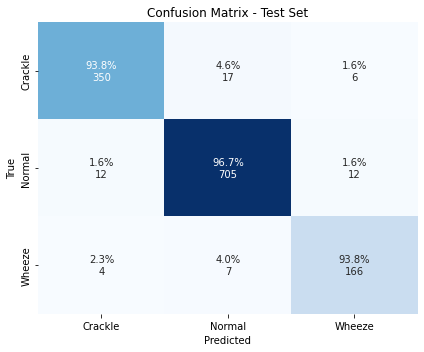

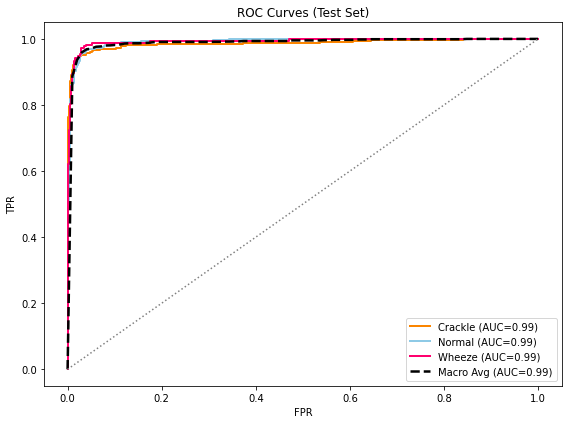

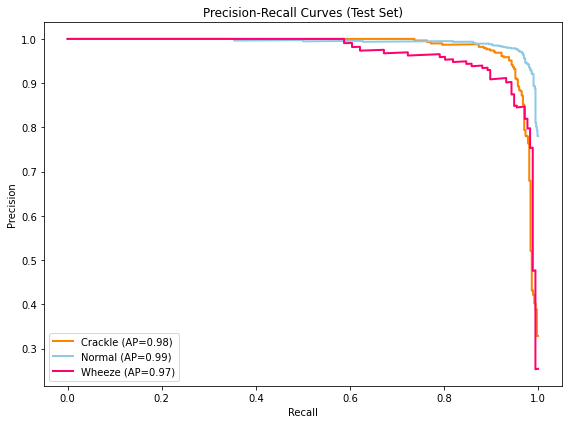

In [67]:
svm_whitening_metrics_df = evaluate_model(X_test, y_test, classes, svm_model)

In [68]:
svm_whitening_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.938338,0.982340,0.956284,0.974808,0.925870,0.960339
1,Normal,0.967078,0.956364,0.967078,0.956364,0.923442,0.961721
2,Wheeze,0.937853,0.983666,0.902174,0.989954,0.906705,0.960760


#### **Random Forest**


Fold 1


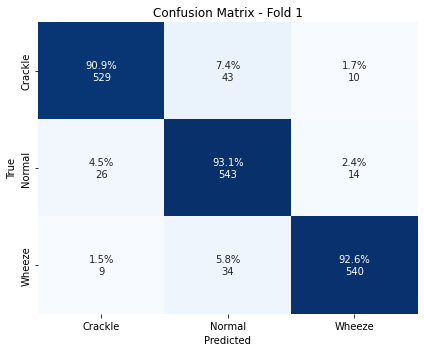

              precision    recall  f1-score   support

     Crackle       0.94      0.91      0.92       582
      Normal       0.88      0.93      0.90       583
      Wheeze       0.96      0.93      0.94       583

    accuracy                           0.92      1748
   macro avg       0.92      0.92      0.92      1748
weighted avg       0.92      0.92      0.92      1748


Fold 2


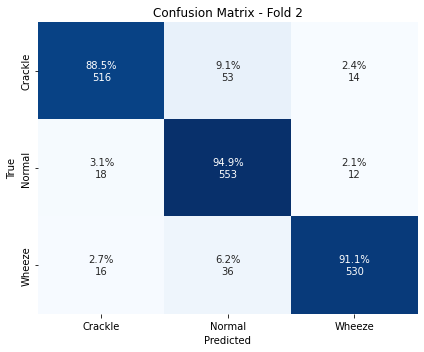

              precision    recall  f1-score   support

     Crackle       0.94      0.89      0.91       583
      Normal       0.86      0.95      0.90       583
      Wheeze       0.95      0.91      0.93       582

    accuracy                           0.91      1748
   macro avg       0.92      0.91      0.92      1748
weighted avg       0.92      0.91      0.92      1748


Fold 3


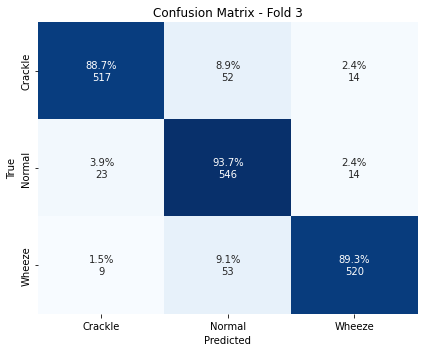

              precision    recall  f1-score   support

     Crackle       0.94      0.89      0.91       583
      Normal       0.84      0.94      0.88       583
      Wheeze       0.95      0.89      0.92       582

    accuracy                           0.91      1748
   macro avg       0.91      0.91      0.91      1748
weighted avg       0.91      0.91      0.91      1748


Fold 4


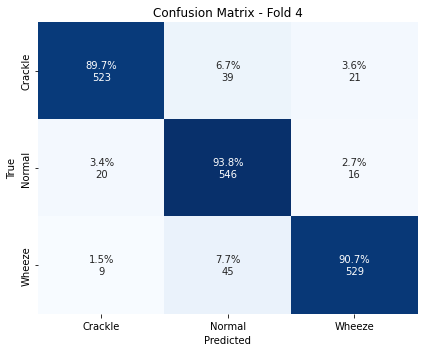

              precision    recall  f1-score   support

     Crackle       0.95      0.90      0.92       583
      Normal       0.87      0.94      0.90       582
      Wheeze       0.93      0.91      0.92       583

    accuracy                           0.91      1748
   macro avg       0.92      0.91      0.91      1748
weighted avg       0.92      0.91      0.91      1748


Fold 5


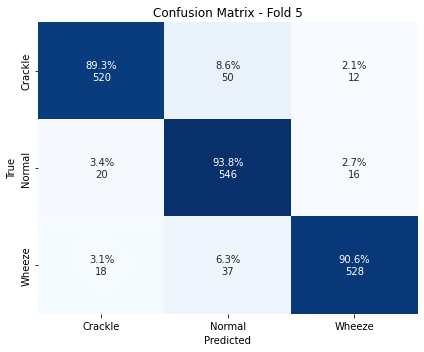

              precision    recall  f1-score   support

     Crackle       0.93      0.89      0.91       582
      Normal       0.86      0.94      0.90       582
      Wheeze       0.95      0.91      0.93       583

    accuracy                           0.91      1747
   macro avg       0.91      0.91      0.91      1747
weighted avg       0.91      0.91      0.91      1747



In [63]:
from statistical_models.random_forest import *

# Train
best_params = {
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 2
}

rf_model = train(X_train, y_train, classes, best_params)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.86      0.83      0.84       373
      Normal       0.87      0.92      0.90       729
      Wheeze       0.87      0.71      0.78       177

    accuracy                           0.87      1279
   macro avg       0.87      0.82      0.84      1279
weighted avg       0.87      0.87      0.86      1279



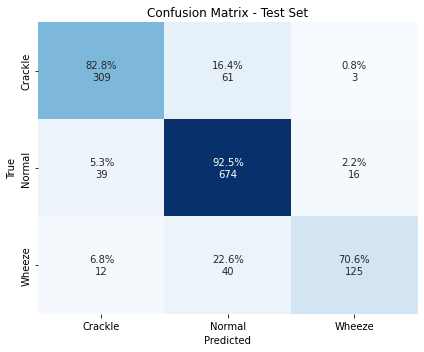

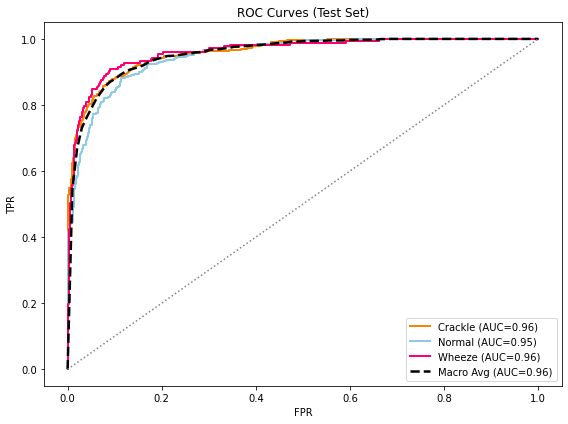

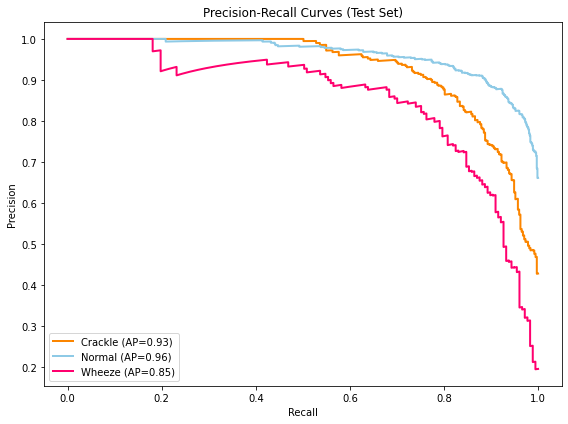

In [64]:
rf_whitening_metrics_df = evaluate_model(X_test, y_test, classes, rf_model)

In [65]:
rf_whitening_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.828418,0.943709,0.858333,0.930359,0.780366,0.886063
1,Normal,0.924554,0.816364,0.869677,0.890873,0.750670,0.870459
2,Wheeze,0.706215,0.982759,0.868056,0.954185,0.752663,0.844487


#### **XGBoost**


Fold 1


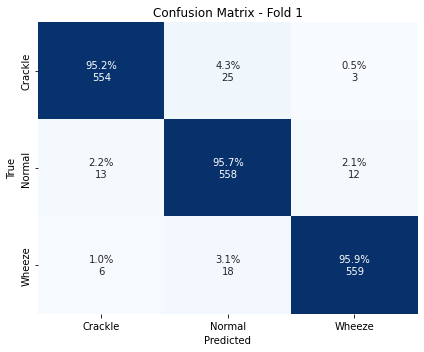

              precision    recall  f1-score   support

     Crackle       0.97      0.95      0.96       582
      Normal       0.93      0.96      0.94       583
      Wheeze       0.97      0.96      0.97       583

    accuracy                           0.96      1748
   macro avg       0.96      0.96      0.96      1748
weighted avg       0.96      0.96      0.96      1748


Fold 2


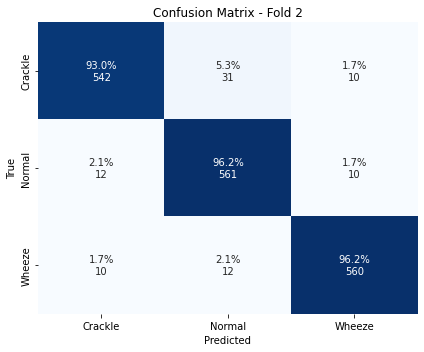

              precision    recall  f1-score   support

     Crackle       0.96      0.93      0.95       583
      Normal       0.93      0.96      0.95       583
      Wheeze       0.97      0.96      0.96       582

    accuracy                           0.95      1748
   macro avg       0.95      0.95      0.95      1748
weighted avg       0.95      0.95      0.95      1748


Fold 3


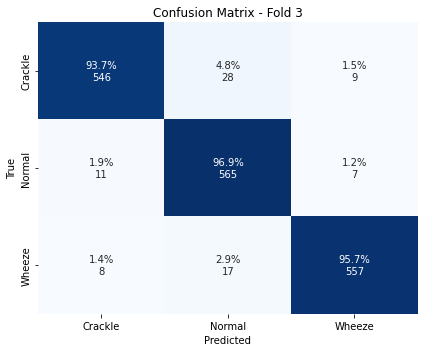

              precision    recall  f1-score   support

     Crackle       0.97      0.94      0.95       583
      Normal       0.93      0.97      0.95       583
      Wheeze       0.97      0.96      0.96       582

    accuracy                           0.95      1748
   macro avg       0.95      0.95      0.95      1748
weighted avg       0.95      0.95      0.95      1748


Fold 4


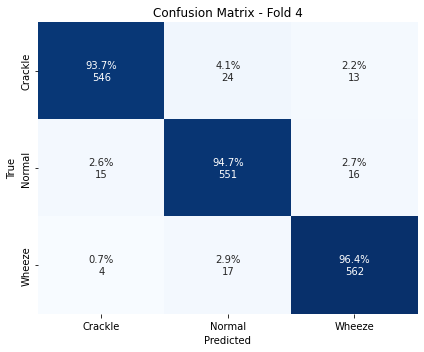

              precision    recall  f1-score   support

     Crackle       0.97      0.94      0.95       583
      Normal       0.93      0.95      0.94       582
      Wheeze       0.95      0.96      0.96       583

    accuracy                           0.95      1748
   macro avg       0.95      0.95      0.95      1748
weighted avg       0.95      0.95      0.95      1748


Fold 5


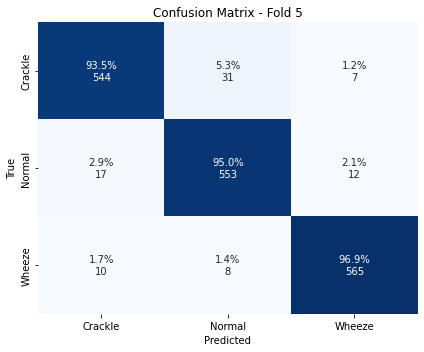

              precision    recall  f1-score   support

     Crackle       0.95      0.93      0.94       582
      Normal       0.93      0.95      0.94       582
      Wheeze       0.97      0.97      0.97       583

    accuracy                           0.95      1747
   macro avg       0.95      0.95      0.95      1747
weighted avg       0.95      0.95      0.95      1747



In [60]:
from statistical_models.xgboost import *

param_dict = {"n_estimators": 200, "max_depth": 5, "learning_rate": 1}
xgb_model = train(X_train, y_train, classes, param_dict)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.92      0.90      0.91       373
      Normal       0.94      0.95      0.94       729
      Wheeze       0.88      0.88      0.88       177

    accuracy                           0.92      1279
   macro avg       0.91      0.91      0.91      1279
weighted avg       0.92      0.92      0.92      1279



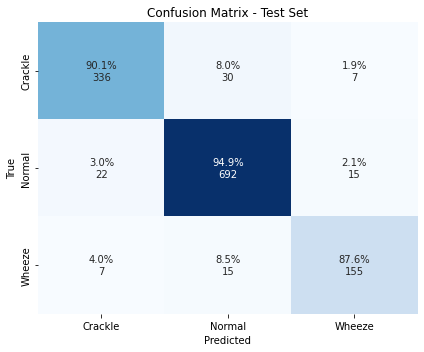

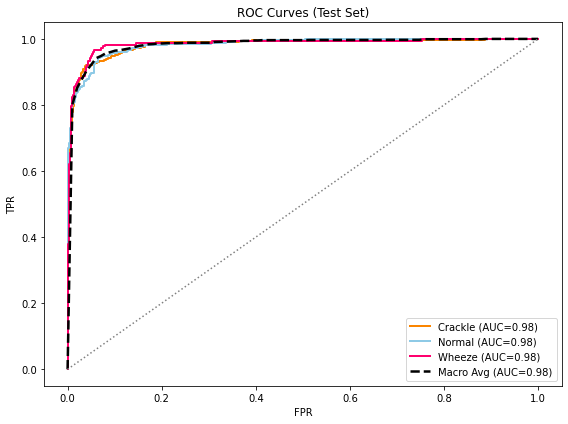

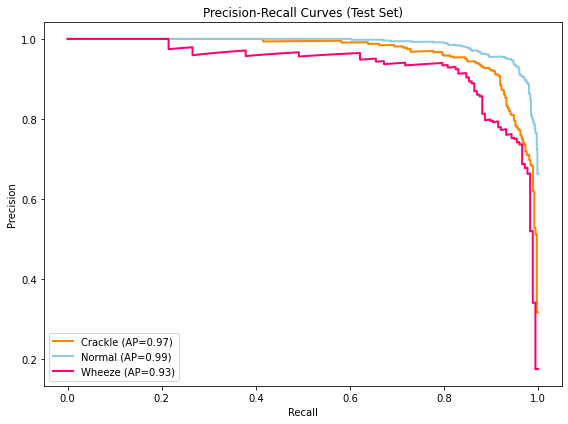

In [61]:
xgb_whitening_metrics_df = evaluate_model(X_test, y_test, classes, xgb_model)

In [62]:
xgb_whitening_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.900804,0.967991,0.920548,0.959519,0.874413,0.934398
1,Normal,0.949246,0.918182,0.938942,0.931734,0.869050,0.933714
2,Wheeze,0.875706,0.980036,0.875706,0.980036,0.855743,0.927871


### **DANN**


 Fold 1


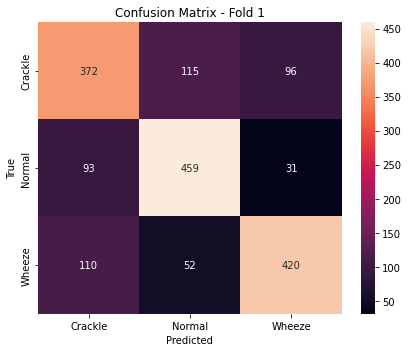

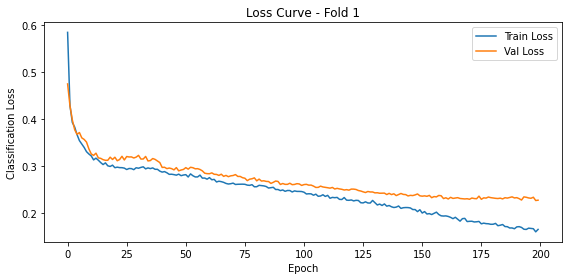


 Fold 2
Early stopping at epoch 64


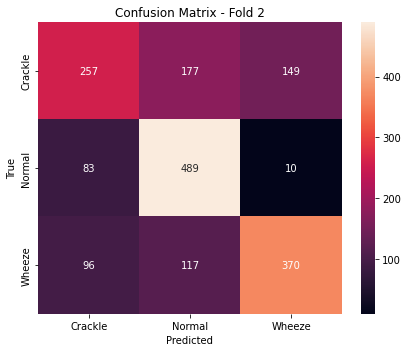

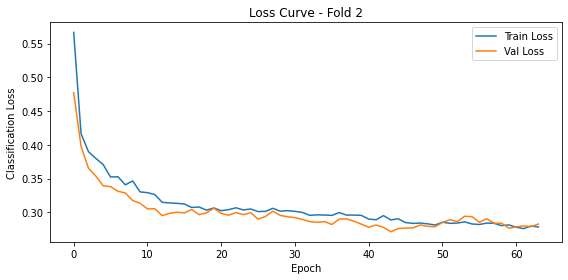


 Fold 3


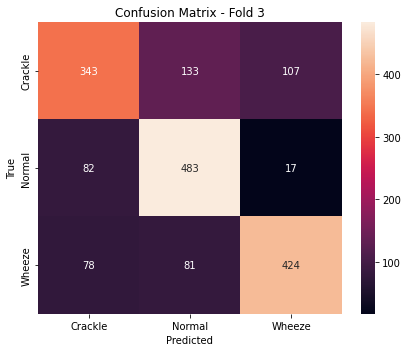

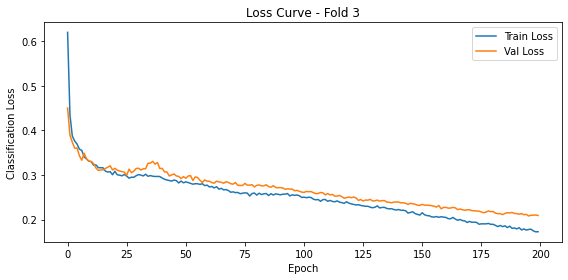


 Fold 4


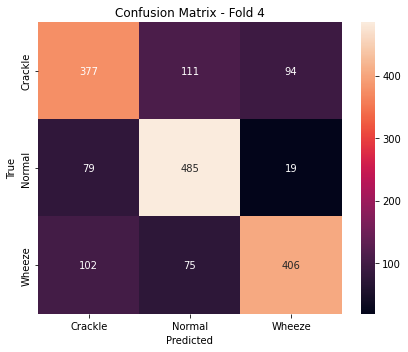

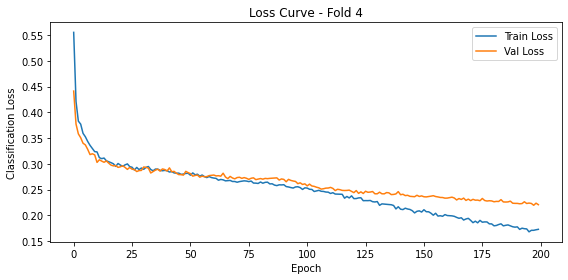


 Fold 5


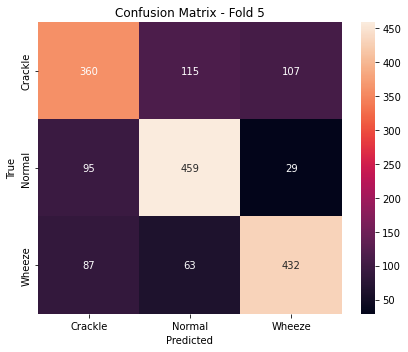

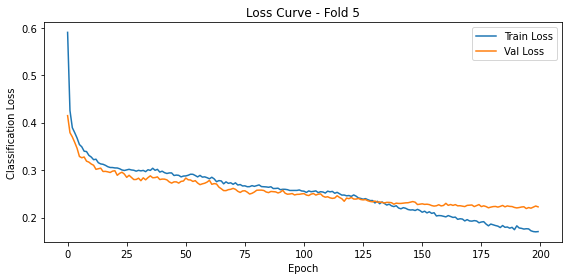

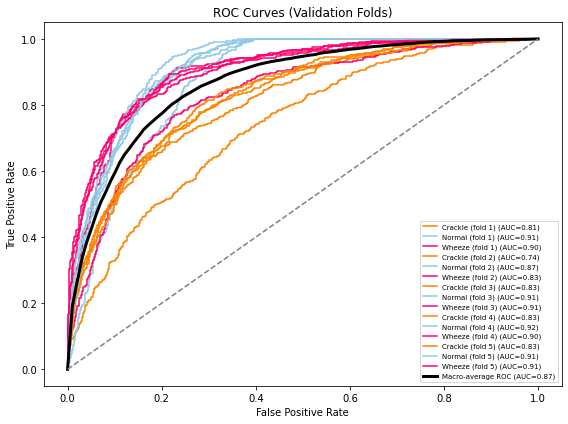

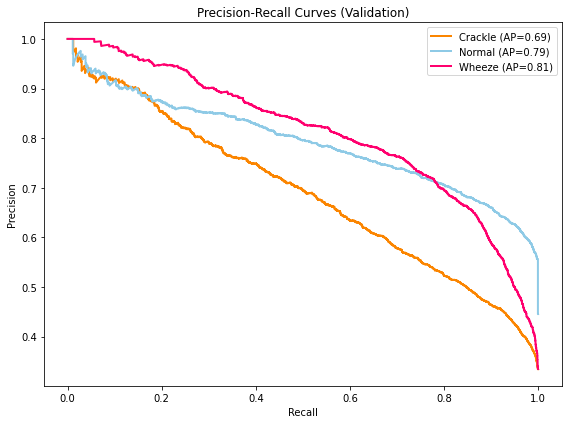

In [48]:
# === SETTINGS ===
import os
import torch
import torch.nn.functional as F
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import pandas as pd
import seaborn as sns

# === Seed ===
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# === Load and Prepare Data ===
x = np.load("training_features.npy")
y = np.load("training_labels.npy")
x_test = np.load("test_features.npy")
y_test = np.load("test_labels.npy")
d = np.load("training_devices.npy", allow_pickle=True)
d_test = np.load("test_devices.npy", allow_pickle=True)

scaler = StandardScaler()
x = scaler.fit_transform(x)
x_test = scaler.transform(x_test)

le_class = LabelEncoder()
y_enc = le_class.fit_transform(y)
y_test_enc = le_class.transform(y_test)
classes = le_class.classes_
n_classes = len(classes)

le_domain = LabelEncoder()
d_enc = le_domain.fit_transform(d)
d_test_enc = le_domain.transform(d_test)

# === Color Map ===
class_colors = {
    "Normal": "#8ecae6",
    "Crackle": "#fb8500",
    "Wheeze": "#ff006e"
}

# === GRL ===
class GradientReversal(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

def revgrad(x, alpha=1.0):
    return GradientReversal.apply(x, alpha)

# === MODULES ===
class FeatureExtractor(nn.Module):
    def __init__(self, input_dim, bottleneck_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, bottleneck_dim)
        )
    def forward(self, x):
        return self.net(x)

class DomainClassifier(nn.Module):
    def __init__(self, bottleneck_dim, num_domains):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(bottleneck_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_domains)
        )
    def forward(self, x, alpha=1.0):
        x = revgrad(x, alpha)
        return self.net(x)

class LabelClassifier(nn.Module):
    def __init__(self, bottleneck_dim=128, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(bottleneck_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# === FOCAL LOSS ===
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal = ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()

# === CV ===
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
input_dim = x.shape[1]
num_domains = len(np.unique(d_enc))

fold = 1
all_probs, all_trues = [], []
train_class_losses, val_class_losses = [], []
best_val_loss = float('inf')
best_models = (None, None)

class_weights = compute_class_weight('balanced', classes=np.unique(y_enc), y=y_enc)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

for train_idx, val_idx in kf.split(x, y_enc):
    print(f"\n Fold {fold}")
    x_train, x_val = x[train_idx], x[val_idx]
    y_train, y_val = y_enc[train_idx], y_enc[val_idx]
    d_train, d_val = d_enc[train_idx], d_enc[val_idx]

    X_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    d_train_tensor = torch.tensor(d_train, dtype=torch.long)
    X_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)
    d_val_tensor = torch.tensor(d_val, dtype=torch.long)

    feature_extractor = FeatureExtractor(input_dim)
    label_classifier = LabelClassifier(bottleneck_dim=128, num_classes=n_classes)
    domain_classifier = DomainClassifier(128, num_domains)

    optimizer = torch.optim.Adam(
        list(feature_extractor.parameters()) +
        list(label_classifier.parameters()) +
        list(domain_classifier.parameters()), lr=1e-3, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
    
    loss_fn_class = FocalLoss(alpha=class_weights_tensor)
    loss_fn_domain = nn.CrossEntropyLoss()


    epochs = 200
    patience = 20
    patience_counter = 0
    train_losses, val_losses = [], []
    best_val = float('inf')

    for epoch in range(epochs):
        feature_extractor.train()
        label_classifier.train()
        domain_classifier.train()

        alpha = 0.5 * (1 + np.cos(np.pi * epoch / epochs))  # Cosine alpha
        feats = feature_extractor(X_train_tensor)
        class_logits = label_classifier(feats)
        domain_logits = domain_classifier(feats, alpha=alpha)

        loss_class = loss_fn_class(class_logits, y_train_tensor)
        loss_domain = loss_fn_domain(domain_logits, d_train_tensor)
        loss_total = (1.2 * loss_class) + (0.5 + 0.5 * alpha) * loss_domain

        optimizer.zero_grad()
        loss_total.backward()
        optimizer.step()

        feature_extractor.eval()
        with torch.no_grad():
            val_feats = feature_extractor(X_val_tensor)
            val_logits = label_classifier(val_feats)
            val_loss_class = loss_fn_class(val_logits, y_val_tensor)

        scheduler.step(val_loss_class.item())
        train_losses.append(loss_class.item())
        val_losses.append(val_loss_class.item())

        if val_loss_class.item() < best_val:
            best_val = val_loss_class.item()
            patience_counter = 0
            torch.save(feature_extractor.state_dict(), "best_feature_extractor.pth")
            torch.save(label_classifier.state_dict(), "best_label_classifier.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    train_class_losses.append(train_losses)
    val_class_losses.append(val_losses)

    with torch.no_grad():
        feats_val = feature_extractor(X_val_tensor)
        logits_val = label_classifier(feats_val)
        probs_val = torch.softmax(logits_val, dim=1).numpy()
        preds_val = np.argmax(probs_val, axis=1)

    all_probs.append(probs_val)
    all_trues.append(y_val)

    cm = confusion_matrix(y_val, preds_val)
 
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Classification Loss")
    plt.title(f"Loss Curve - Fold {fold}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    fold += 1

# === ROC Curves from All Folds ===
plt.figure(figsize=(8, 6))
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (probs, trues) in enumerate(zip(all_probs, all_trues), 1):
    trues_bin = label_binarize(trues, classes=range(n_classes))
    for j, class_name in enumerate(classes):
        fpr, tpr, _ = roc_curve(trues_bin[:, j], probs[:, j])
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        all_tpr.append(interp_tpr)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=1.5, color=class_colors[class_name],
                 label=f"{class_name} (fold {i}) (AUC={roc_auc:.2f})")

mean_tpr = np.mean(all_tpr, axis=0)
mean_tpr[-1] = 1.0
macro_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, color='black', linewidth=3,
         label=f"Macro-average ROC (AUC={macro_auc:.2f})")
plt.plot([0, 1], [0, 1], 'gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Validation Folds)")
plt.legend(fontsize="x-small")
plt.tight_layout()
plt.show()

# === PR Curves ===
final_probs = np.concatenate(all_probs)
final_trues = np.concatenate(all_trues)
final_trues_bin = label_binarize(final_trues, classes=range(n_classes))

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    precision, recall, _ = precision_recall_curve(final_trues_bin[:, i], final_probs[:, i])
    ap = average_precision_score(final_trues_bin[:, i], final_probs[:, i])
    plt.plot(recall, precision, color=class_colors[class_name], lw=2,
             label=f"{class_name} (AP={ap:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Validation)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# === Load Best Model for Test Set Evaluation ===
feature_extractor = FeatureExtractor(input_dim=x.shape[1])
label_classifier = LabelClassifier(bottleneck_dim=128, num_classes=n_classes)
feature_extractor.load_state_dict(torch.load("best_feature_extractor.pth"))
label_classifier.load_state_dict(torch.load("best_label_classifier.pth"))
feature_extractor.eval()
label_classifier.eval()

X_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

with torch.no_grad():
    feats_test = feature_extractor(X_test_tensor)
    logits_test = label_classifier(feats_test)
    probs_test = torch.softmax(logits_test, dim=1).numpy()
    preds_test = np.argmax(probs_test, axis=1)

# === Classification Report ===
print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test_enc, preds_test, target_names=classes))

# === Confusion Matrix ===
cm_test = confusion_matrix(y_test_enc, preds_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# === ROC Curves (Test Set) ===
y_test_bin = label_binarize(y_test_enc, classes=range(n_classes))
plt.figure(figsize=(8, 6))
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs_test[:, i])
    auc_val = auc(fpr, tpr)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    all_tpr.append(interp_tpr)
    plt.plot(fpr, tpr, lw=2, color=class_colors[class_name], label=f"{class_name} (AUC={auc_val:.2f})")

mean_tpr = np.mean(all_tpr, axis=0)
mean_tpr[-1] = 1.0
macro_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, color="black", lw=3, label=f"Macro-Average (AUC={macro_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

# === PR Curves (Test Set) ===
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs_test[:, i])
    ap = average_precision_score(y_test_bin[:, i], probs_test[:, i])
    plt.plot(recall, precision, lw=2, color=class_colors[class_name], label=f"{class_name} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curves (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

# === Custom Metrics DataFrame ===
mcm = multilabel_confusion_matrix(y_test_enc, preds_test, labels=range(n_classes))
metrics = []

for i, label in enumerate(classes):
    tn, fp, fn, tp = mcm[i].ravel()
    SE = tp / (tp + fn + 1e-6)
    SP = tn / (tn + fp + 1e-6)
    PPV = tp / (tp + fp + 1e-6)
    NPV = tn / (tn + fn + 1e-6)
    MCC = (tp * tn - fp * fn) / (np.sqrt((tp + fp)*(tp + fn)*(tn + fp)*(tn + fn)) + 1e-6)
    SCORE = (SE + SP) / 2
    metrics.append({
        "Class": label,
        "Sensitivity (SE)": SE,
        "Specificity (SP)": SP,
        "PPV": PPV,
        "NPV": NPV,
        "MCC": MCC,
        "SCORE": SCORE
    })

metrics_df = pd.DataFrame(metrics)

In [88]:
# === SETTINGS ===
import os
import torch
import torch.nn.functional as F
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import pandas as pd
import seaborn as sns

# === Seed ===
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# === Load and Prepare Data ===
x = np.load("training_features.npy")
y = np.load("training_labels.npy")
x_test = np.load("test_features.npy")
y_test = np.load("test_labels.npy")
d = np.load("training_devices.npy", allow_pickle=True)
d_test = np.load("test_devices.npy", allow_pickle=True)

scaler = StandardScaler()
x = scaler.fit_transform(x)
x_test = scaler.transform(x_test)

le_class = LabelEncoder()
y_enc = le_class.fit_transform(y)
y_test_enc = le_class.transform(y_test)
classes = le_class.classes_
n_classes = len(classes)

le_domain = LabelEncoder()
d_enc = le_domain.fit_transform(d)
d_test_enc = le_domain.transform(d_test)

# === Auxiliary binary labels ===
y_aux = (y_enc != le_class.transform(['Normal'])[0]).astype(int)

# === Color Map ===
class_colors = {
    "Normal": "#8ecae6",
    "Crackle": "#fb8500",
    "Wheeze": "#ff006e"
}

# === GRL ===
class GradientReversal(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

def revgrad(x, alpha=1.0):
    return GradientReversal.apply(x, alpha)

# === MODULES ===
class FeatureExtractor(nn.Module):
    def __init__(self, input_dim, bottleneck_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, bottleneck_dim)
        )

    def forward(self, x):
        return self.net(x)


class DomainClassifier(nn.Module):
    def __init__(self, bottleneck_dim, num_domains):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(bottleneck_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_domains)
        )
    def forward(self, x, alpha=1.0):
        x = revgrad(x, alpha)
        return self.net(x)

class LabelClassifier(nn.Module):
    def __init__(self, bottleneck_dim=128, num_classes=3):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(bottleneck_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.main_head = nn.Linear(128, num_classes)
        self.aux_head = nn.Linear(128, 2)

    def forward(self, x):
        h = self.shared(x)
        return self.main_head(h), self.aux_head(h)

# === FOCAL LOSS ===
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal = ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()

# === CV ===
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
input_dim = x.shape[1]
num_domains = len(np.unique(d_enc))

fold = 1
all_probs, all_trues = [], []
train_class_losses, val_class_losses = [], []

class_weights = compute_class_weight('balanced', classes=np.unique(y_enc), y=y_enc)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

for train_idx, val_idx in kf.split(x, y_enc):
    print(f"\n Fold {fold}")
    x_train, x_val = x[train_idx], x[val_idx]
    y_train, y_val = y_enc[train_idx], y_enc[val_idx]
    d_train, d_val = d_enc[train_idx], d_enc[val_idx]
    y_train_aux = y_aux[train_idx]
    y_val_aux = y_aux[val_idx]

    X_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_train_aux_tensor = torch.tensor(y_train_aux, dtype=torch.long)
    d_train_tensor = torch.tensor(d_train, dtype=torch.long)

    X_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)
    y_val_aux_tensor = torch.tensor(y_val_aux, dtype=torch.long)
    d_val_tensor = torch.tensor(d_val, dtype=torch.long)

    feature_extractor = FeatureExtractor(input_dim)
    label_classifier = LabelClassifier(bottleneck_dim=32, num_classes=n_classes)
    domain_classifier = DomainClassifier(32, num_domains)

    optimizer = torch.optim.Adam(
        list(feature_extractor.parameters()) +
        list(label_classifier.parameters()) +
        list(domain_classifier.parameters()), lr=1e-3, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

    loss_fn_class = FocalLoss(alpha=class_weights_tensor)
    loss_fn_aux = nn.CrossEntropyLoss()
    loss_fn_domain = nn.CrossEntropyLoss()

    epochs = 200
    patience = 20
    patience_counter = 0
    train_losses, val_losses = [], []
    best_val = float('inf')

    train_domain_losses = []
    val_domain_losses = []

    for epoch in range(epochs):
        feature_extractor.train()
        label_classifier.train()
        domain_classifier.train()

        alpha_val = 0.5 * (1 + np.cos(np.pi * epoch / epochs))
        feats = feature_extractor(X_train_tensor)
        class_logits, aux_logits = label_classifier(feats)
        domain_logits = domain_classifier(feats, alpha=alpha_val)

        loss_class = loss_fn_class(class_logits, y_train_tensor)
        loss_aux = loss_fn_aux(aux_logits, y_train_aux_tensor)
        loss_domain = loss_fn_domain(domain_logits, d_train_tensor)

        loss_total = (1.2 * loss_class) + (0.3 * loss_aux) + (0.5 + 0.5 * alpha_val) * loss_domain

        optimizer.zero_grad()
        loss_total.backward()
        optimizer.step()

        feature_extractor.eval()
        with torch.no_grad():
            val_feats = feature_extractor(X_val_tensor)
            val_class_logits, _ = label_classifier(val_feats)
            val_domain_logits = domain_classifier(val_feats, alpha=alpha_val)
            val_loss_class = loss_fn_class(val_class_logits, y_val_tensor)
            val_loss_domain = loss_fn_domain(val_domain_logits, d_val_tensor)

        scheduler.step(val_loss_class.item())
        train_losses.append(loss_class.item())
        val_losses.append(val_loss_class.item())
        train_domain_losses.append(loss_domain.item())
        val_domain_losses.append(val_loss_domain.item())

        if val_loss_class.item() < best_val:
            best_val = val_loss_class.item()
            patience_counter = 0
            torch.save(feature_extractor.state_dict(), "best_feature_extractor.pth")
            torch.save(label_classifier.state_dict(), "best_label_classifier.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break


    train_class_losses.append(train_losses)
    val_class_losses.append(val_losses)

    with torch.no_grad():
        feats_val = feature_extractor(X_val_tensor)
        logits_val, _ = label_classifier(feats_val)
        probs_val = torch.softmax(logits_val, dim=1).numpy()
        preds_val = np.argmax(probs_val, axis=1)

    all_probs.append(probs_val)
    all_trues.append(y_val)

    cm = confusion_matrix(y_val, preds_val)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Label Classification Loss")
    plt.title(f"Loss Curve - Fold {fold}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(train_domain_losses, label="Train Domain Loss")
    plt.plot(val_domain_losses, label="Val Domain Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Domain Classification Loss")
    plt.title(f"Domain Loss Curve - Fold {fold}")
    plt.legend()
    plt.tight_layout()
    plt.show()


    fold += 1

# === ROC Curves from All Folds ===
plt.figure(figsize=(8, 6))
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (probs, trues) in enumerate(zip(all_probs, all_trues), 1):
    trues_bin = label_binarize(trues, classes=range(n_classes))
    for j, class_name in enumerate(classes):
        fpr, tpr, _ = roc_curve(trues_bin[:, j], probs[:, j])
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        all_tpr.append(interp_tpr)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=1.5, color=class_colors[class_name],
                 label=f"{class_name} (fold {i}) (AUC={roc_auc:.2f})")

mean_tpr = np.mean(all_tpr, axis=0)
mean_tpr[-1] = 1.0
macro_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, color='black', linewidth=3,
         label=f"Macro-average ROC (AUC={macro_auc:.2f})")
plt.plot([0, 1], [0, 1], 'gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Validation Folds)")
plt.legend(fontsize="x-small")
plt.tight_layout()
plt.show()

# === PR Curves ===
final_probs = np.concatenate(all_probs)
final_trues = np.concatenate(all_trues)
final_trues_bin = label_binarize(final_trues, classes=range(n_classes))

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    precision, recall, _ = precision_recall_curve(final_trues_bin[:, i], final_probs[:, i])
    ap = average_precision_score(final_trues_bin[:, i], final_probs[:, i])
    plt.plot(recall, precision, color=class_colors[class_name], lw=2,
             label=f"{class_name} (AP={ap:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Validation)")
plt.legend()
plt.tight_layout()
plt.show()



 Fold 1


KeyboardInterrupt: 

In [71]:
metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.651475,0.874172,0.680672,0.859002,0.532614,0.762823
1,Normal,0.788752,0.660000,0.754593,0.702128,0.452719,0.724376
2,Wheeze,0.553672,0.943739,0.612500,0.929401,0.519180,0.748705



 Fold 1
Early stopping at epoch 140


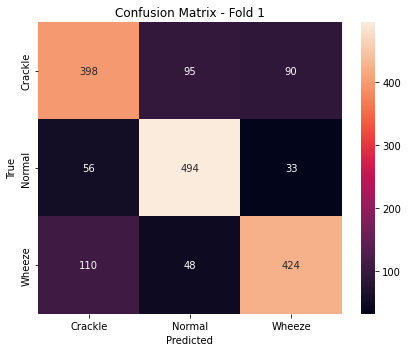

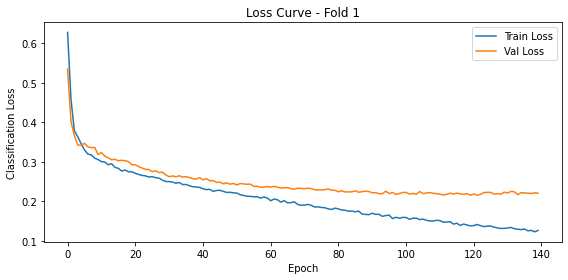


 Fold 2
Early stopping at epoch 139


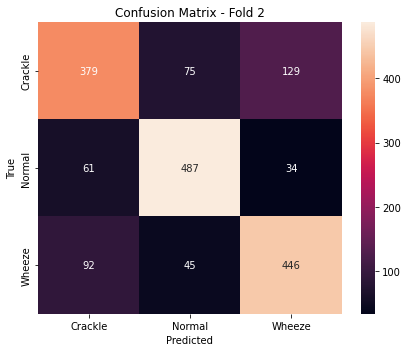

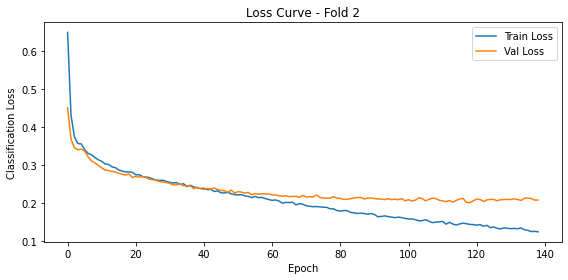


 Fold 3
Early stopping at epoch 146


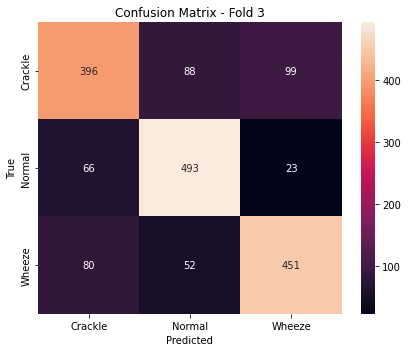

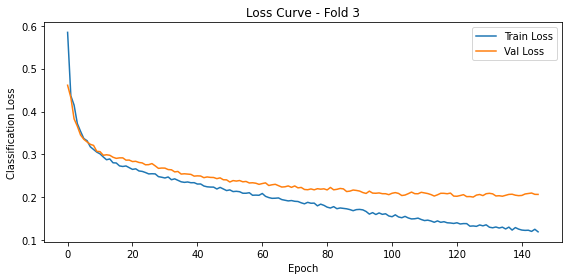


 Fold 4
Early stopping at epoch 132


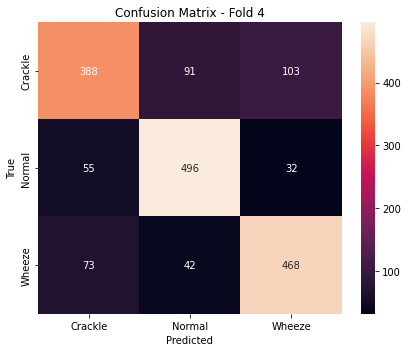

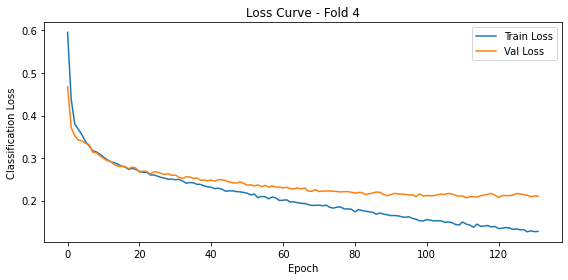


 Fold 5
Early stopping at epoch 135


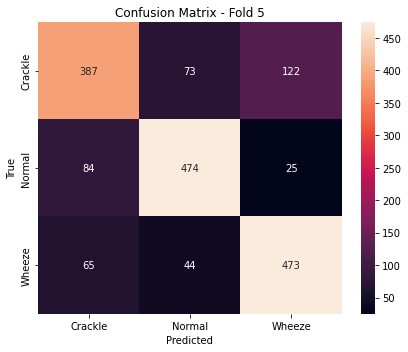

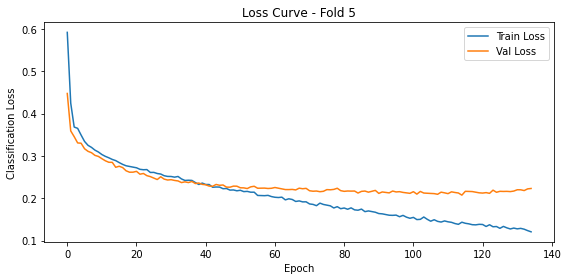

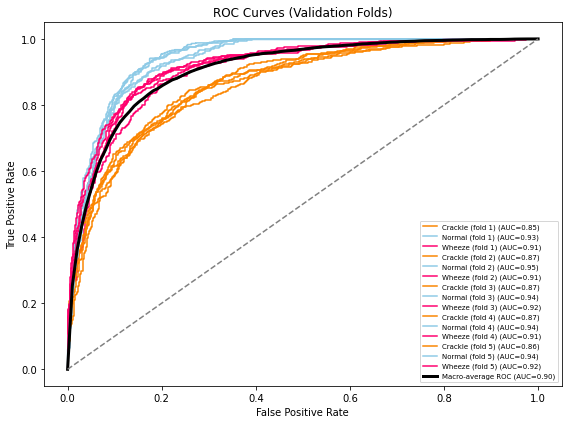

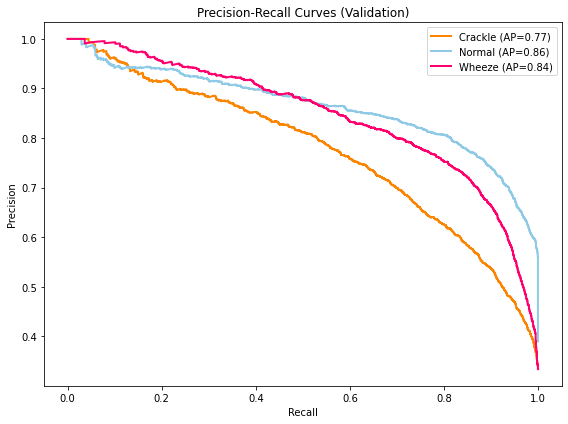

In [67]:
# === SETTINGS ===
import os
import torch
import torch.nn.functional as F
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import pandas as pd
import seaborn as sns

# === Seed ===
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# === Load and Prepare Data ===
x = np.load("training_features.npy")
y = np.load("training_labels.npy")
x_test = np.load("test_features.npy")
y_test = np.load("test_labels.npy")

scaler = StandardScaler()
x = scaler.fit_transform(x)
x_test = scaler.transform(x_test)

le_class = LabelEncoder()
y_enc = le_class.fit_transform(y)
y_test_enc = le_class.transform(y_test)
classes = le_class.classes_
n_classes = len(classes)

# === Auxiliary binary labels ===
y_aux = (y_enc != le_class.transform(['Normal'])[0]).astype(int)

# === Color Map ===
class_colors = {
    "Normal": "#8ecae6",
    "Crackle": "#fb8500",
    "Wheeze": "#ff006e"
}

# === MODULES ===
class FeatureExtractor(nn.Module):
    def __init__(self, input_dim, bottleneck_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, bottleneck_dim)
        )
    def forward(self, x):
        return self.net(x)

class LabelClassifier(nn.Module):
    def __init__(self, bottleneck_dim=256, num_classes=3):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(bottleneck_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.main_head = nn.Linear(128, num_classes)
        self.aux_head = nn.Linear(128, 2)

    def forward(self, x):
        h = self.shared(x)
        return self.main_head(h), self.aux_head(h)

# === FOCAL LOSS ===
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal = ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()

# === CV ===
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
input_dim = x.shape[1]

fold = 1
all_probs, all_trues = [], []
train_class_losses, val_class_losses = [], []

class_weights = compute_class_weight('balanced', classes=np.unique(y_enc), y=y_enc)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

for train_idx, val_idx in kf.split(x, y_enc):
    print(f"\n Fold {fold}")
    x_train, x_val = x[train_idx], x[val_idx]
    y_train, y_val = y_enc[train_idx], y_enc[val_idx]
    y_train_aux = y_aux[train_idx]
    y_val_aux = y_aux[val_idx]

    X_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_train_aux_tensor = torch.tensor(y_train_aux, dtype=torch.long)

    X_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)
    y_val_aux_tensor = torch.tensor(y_val_aux, dtype=torch.long)

    feature_extractor = FeatureExtractor(input_dim)
    label_classifier = LabelClassifier(bottleneck_dim=256, num_classes=n_classes)

    optimizer = torch.optim.Adam(
        list(feature_extractor.parameters()) + list(label_classifier.parameters()),
        lr=1e-3, weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

    loss_fn_class = FocalLoss(alpha=class_weights_tensor)
    loss_fn_aux = nn.CrossEntropyLoss()

    epochs = 200
    patience = 20
    patience_counter = 0
    train_losses, val_losses = [], []
    best_val = float('inf')

    for epoch in range(epochs):
        feature_extractor.train()
        label_classifier.train()

        feats = feature_extractor(X_train_tensor)
        class_logits, aux_logits = label_classifier(feats)

        loss_class = loss_fn_class(class_logits, y_train_tensor)
        loss_aux = loss_fn_aux(aux_logits, y_train_aux_tensor)

        loss_total = (1.2 * loss_class) + (0.3 * loss_aux)

        optimizer.zero_grad()
        loss_total.backward()
        optimizer.step()

        feature_extractor.eval()
        with torch.no_grad():
            val_feats = feature_extractor(X_val_tensor)
            val_class_logits, _ = label_classifier(val_feats)
            val_loss_class = loss_fn_class(val_class_logits, y_val_tensor)

        scheduler.step(val_loss_class.item())
        train_losses.append(loss_class.item())
        val_losses.append(val_loss_class.item())

        if val_loss_class.item() < best_val:
            best_val = val_loss_class.item()
            patience_counter = 0
            torch.save(feature_extractor.state_dict(), "best_feature_extractor.pth")
            torch.save(label_classifier.state_dict(), "best_label_classifier.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    train_class_losses.append(train_losses)
    val_class_losses.append(val_losses)

    with torch.no_grad():
        feats_val = feature_extractor(X_val_tensor)
        logits_val, _ = label_classifier(feats_val)
        probs_val = torch.softmax(logits_val, dim=1).numpy()
        preds_val = np.argmax(probs_val, axis=1)

    all_probs.append(probs_val)
    all_trues.append(y_val)

    cm = confusion_matrix(y_val, preds_val)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Classification Loss")
    plt.title(f"Loss Curve - Fold {fold}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    fold += 1

# === ROC Curves from All Folds ===
plt.figure(figsize=(8, 6))
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (probs, trues) in enumerate(zip(all_probs, all_trues), 1):
    trues_bin = label_binarize(trues, classes=range(n_classes))
    for j, class_name in enumerate(classes):
        fpr, tpr, _ = roc_curve(trues_bin[:, j], probs[:, j])
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        all_tpr.append(interp_tpr)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=1.5, color=class_colors[class_name],
                 label=f"{class_name} (fold {i}) (AUC={roc_auc:.2f})")

mean_tpr = np.mean(all_tpr, axis=0)
mean_tpr[-1] = 1.0
macro_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, color='black', linewidth=3,
         label=f"Macro-average ROC (AUC={macro_auc:.2f})")
plt.plot([0, 1], [0, 1], 'gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Validation Folds)")
plt.legend(fontsize="x-small")
plt.tight_layout()
plt.show()

# === PR Curves ===
final_probs = np.concatenate(all_probs)
final_trues = np.concatenate(all_trues)
final_trues_bin = label_binarize(final_trues, classes=range(n_classes))

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    precision, recall, _ = precision_recall_curve(final_trues_bin[:, i], final_probs[:, i])
    ap = average_precision_score(final_trues_bin[:, i], final_probs[:, i])
    plt.plot(recall, precision, color=class_colors[class_name], lw=2,
             label=f"{class_name} (AP={ap:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Validation)")
plt.legend()
plt.tight_layout()
plt.show()



=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

     Crackle       0.69      0.68      0.68       373
      Normal       0.77      0.78      0.77       729
      Wheeze       0.63      0.62      0.63       177

    accuracy                           0.73      1279
   macro avg       0.70      0.69      0.69      1279
weighted avg       0.73      0.73      0.73      1279



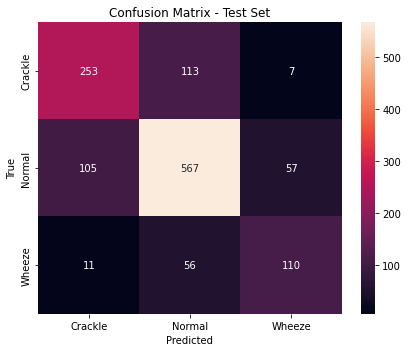

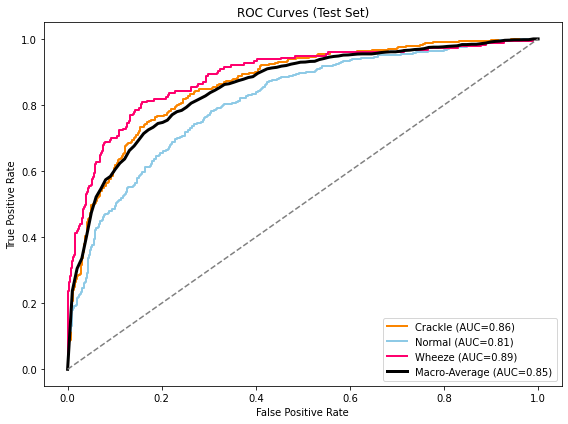

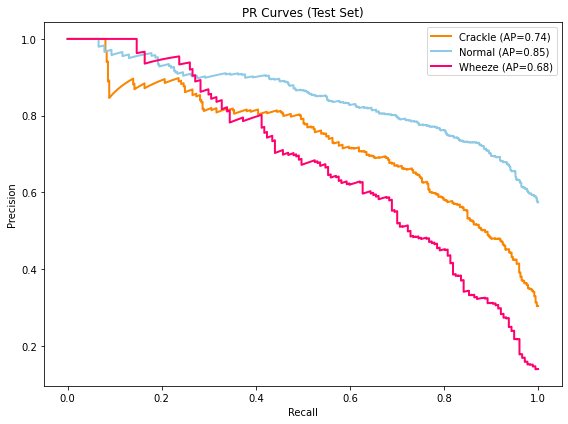

     Class  Sensitivity (SE)  Specificity (SP)       PPV       NPV       MCC  \
0  Crackle          0.678284          0.871965  0.685637  0.868132  0.552006   
1   Normal          0.777778          0.692727  0.770380  0.701657  0.471271   
2   Wheeze          0.621469          0.941924  0.632184  0.939367  0.567457   

      SCORE  
0  0.775124  
1  0.735253  
2  0.781696  


In [68]:
# === Load Best Model for Test Set Evaluation ===
feature_extractor = FeatureExtractor(input_dim=x.shape[1], bottleneck_dim=256)
label_classifier = LabelClassifier(bottleneck_dim=256, num_classes=n_classes)

feature_extractor.load_state_dict(torch.load("best_feature_extractor.pth"))
label_classifier.load_state_dict(torch.load("best_label_classifier.pth"))
feature_extractor.eval()
label_classifier.eval()

X_test_tensor = torch.tensor(x_test, dtype=torch.float32)

with torch.no_grad():
    feats_test = feature_extractor(X_test_tensor)
    main_logits, aux_logits = label_classifier(feats_test)
    probs_test = torch.softmax(main_logits, dim=1).numpy()
    preds_test = np.argmax(probs_test, axis=1)

# === Classification Report ===
print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test_enc, preds_test, target_names=classes))

# === Confusion Matrix ===
cm_test = confusion_matrix(y_test_enc, preds_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# === ROC Curves (Test Set) ===
y_test_bin = label_binarize(y_test_enc, classes=range(n_classes))
plt.figure(figsize=(8, 6))
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs_test[:, i])
    auc_val = auc(fpr, tpr)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    all_tpr.append(interp_tpr)
    plt.plot(fpr, tpr, lw=2, color=class_colors[class_name],
             label=f"{class_name} (AUC={auc_val:.2f})")

mean_tpr = np.mean(all_tpr, axis=0)
mean_tpr[-1] = 1.0
macro_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, color="black", lw=3,
         label=f"Macro-Average (AUC={macro_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

# === PR Curves (Test Set) ===
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs_test[:, i])
    ap = average_precision_score(y_test_bin[:, i], probs_test[:, i])
    plt.plot(recall, precision, lw=2, color=class_colors[class_name],
             label=f"{class_name} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curves (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

# === Custom Metrics DataFrame ===
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(y_test_enc, preds_test, labels=range(n_classes))
metrics = []

for i, label in enumerate(classes):
    tn, fp, fn, tp = mcm[i].ravel()
    SE = tp / (tp + fn + 1e-6)
    SP = tn / (tn + fp + 1e-6)
    PPV = tp / (tp + fp + 1e-6)
    NPV = tn / (tn + fn + 1e-6)
    MCC = (tp * tn - fp * fn) / (np.sqrt((tp + fp)*(tp + fn)*(tn + fp)*(tn + fn)) + 1e-6)
    SCORE = (SE + SP) / 2
    metrics.append({
        "Class": label,
        "Sensitivity (SE)": SE,
        "Specificity (SP)": SP,
        "PPV": PPV,
        "NPV": NPV,
        "MCC": MCC,
        "SCORE": SCORE
    })

metrics_df = pd.DataFrame(metrics)
print(metrics_df)
